In [1]:
# Add repo root to sys.path so the package can be imported in-kernel
import sys
from pathlib import Path
# repo_root should point to the repository root (parent of RTD_Calibration_VGP)
repo_root = Path('..').resolve().parent if (Path('..').resolve().name == 'RTD_Calibration_VGP') else Path('..').resolve()
# ensure the repository root is the parent that contains RTD_Calibration_VGP
if (repo_root / 'RTD_Calibration_VGP').exists():
    sys.path.insert(0, str(repo_root))
    print('Inserted repo root into sys.path:', repo_root)
else:
    # fallback: insert the immediate parent and warn
    sys.path.insert(0, str(Path('..').resolve()))
    print('Warning: expected repo layout not found; inserted', Path('..').resolve(), 'into sys.path')

# Force reload modules to pick up recent code changes
import importlib
import RTD_Calibration_VGP.src.set
import RTD_Calibration_VGP.src.run
import RTD_Calibration_VGP.src.logfile
importlib.reload(RTD_Calibration_VGP.src.set)
importlib.reload(RTD_Calibration_VGP.src.run)
importlib.reload(RTD_Calibration_VGP.src.logfile)

# Import local modules via package namespace
from RTD_Calibration_VGP.src.logfile import Logfile
from RTD_Calibration_VGP.src.run import Run
from RTD_Calibration_VGP.src.set import Set
import pandas as pd

# Read the logfile from repo data folder (guard if missing)
logfile_path = (repo_root / 'RTD_Calibration_VGP' / 'data' / 'LogFile.csv').resolve() if (repo_root / 'RTD_Calibration_VGP').exists() else (repo_root / 'data' / 'LogFile.csv').resolve()
if not logfile_path.exists():
    print(f'Warning: logfile not found at {logfile_path}. Create or provide RTD_Calibration_VGP/data/LogFile.csv before running data processing cells.')
    logfile_df = pd.DataFrame()
else:
    logfiles = Logfile(filepath=str(logfile_path))
    logfile_df = logfiles.log_file

# Select sets to process - todos los sets con datos disponibles
# Según config.yml: Round 1 (3-48, 59-60), Round 2 (49-55), Round 3 (57, 62), Round 4 (63)
selected_sets = list(range(3, 49)) + list(range(49, 56)) + [57, 59, 60, 62, 63]  # Todos los sets disponibles

# Use the external YAML config to load round info and sensor mappings
config_path = (repo_root / 'RTD_Calibration_VGP' / 'config' / 'config.yml').resolve()
if config_path.exists():
    print(f'Using config: {config_path}')
    set_instance = Set(logfile=logfile_df, config_path=str(config_path))
else:
    print(f'Warning: config.yml not found at {config_path}, using defaults')
    set_instance = Set(logfile=logfile_df)

# If logfile_df is empty the following calls will be no-ops or produce warnings
set_instance.group_runs_by_set(selected_sets=selected_sets)
set_instance.calculate_offsets_and_rms(selected_sets=selected_sets)
# Use outputs/ directory for generated plots
set_instance.offset_repeatability(selected_sets=selected_sets, ref=2, write_csv=True, save_dir='outputs/plot_global_means')

# Weighted mean offsets and errors
calibration_constants, calibration_errors = set_instance.calculate_weighted_mean_offsets(selected_sets=selected_sets)

print('Set processing complete. You can now run the plotting cells to generate figures.')
print(f'Loaded {len(set_instance.set_rounds)} sets with round info from config.yml')

Inserted repo root into sys.path: /Users/vicky/Desktop/rtd-calibration-ana
CSV file loaded successfully from '/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/LogFile.csv'.
Using config: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/config/config.yml

Processing CalibSetNumber: 3.0
    Excluded: 20220526_ln2_r48176_r48177_48060_48479_1_pre (contains 'pre' or 'st')
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_1_pre (contains 'pre' or 'st')
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_1 (marked as 'BAD' in Selection)
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_2_pre (contains 'pre' or 'st')
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_2 (marked as 'BAD' in Selection)
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_3 (marked as 'BAD' in Selection)
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_4_pre (contains 'pre' or 'st')
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_4 (marked as 'BAD' in Selection)
    E

/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/src/set.py:812: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend(fontsize=8, loc="upper left", ncol=1)


Plot saved to: outputs/plot_global_means/offset_repeatability_set_30.png

Processing CalibSetNumber: 31
OK: Set 31: Using dynamic references from raised sensors in channels [3, 9]
  [Sensor Ch 1 vs Ref Ch 3 | Run 1] Mean: 253.407 mK, Std: 0.741 mK
  [Sensor Ch 1 vs Ref Ch 3 | Run 2] Mean: 250.278 mK, Std: 0.339 mK
  [Sensor Ch 1 vs Ref Ch 3 | Run 3] Mean: 245.080 mK, Std: 0.316 mK
  [Sensor Ch 1 vs Ref Ch 3 | Run 4] Mean: 245.703 mK, Std: 0.485 mK
  [Sensor Ch 2 vs Ref Ch 3 | Run 1] Mean: 227.953 mK, Std: 0.638 mK
  [Sensor Ch 2 vs Ref Ch 3 | Run 2] Mean: 230.148 mK, Std: 0.260 mK
  [Sensor Ch 2 vs Ref Ch 3 | Run 3] Mean: 228.734 mK, Std: 0.258 mK
  [Sensor Ch 2 vs Ref Ch 3 | Run 4] Mean: 229.655 mK, Std: 0.345 mK
  [Sensor Ch 3 vs Ref Ch 9 | Run 1] Mean: -284.920 mK, Std: 0.738 mK
  [Sensor Ch 3 vs Ref Ch 9 | Run 2] Mean: -287.318 mK, Std: 0.342 mK
  [Sensor Ch 3 vs Ref Ch 9 | Run 3] Mean: -283.702 mK, Std: 0.319 mK
  [Sensor Ch 3 vs Ref Ch 9 | Run 4] Mean: -286.864 mK, Std: 0.626 mK


Processing 56 sets.
Set 3: len sensor_names=9, len global_means=9
  First sensor_name: '48060' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-66.35545269405011) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 4: len sensor_names=9, len global_means=9
  First sensor_name: '48480' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-13.924798414992452) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 5: len sensor_names=10, len global_means=10
  First sensor_name: '48492' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-33.899152223248684) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 6: len sensor_names=9, len global_means=9
  First sensor_name: '48726' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-26.16033667765956) (type: <class 'numpy.float64'>)
  All glo

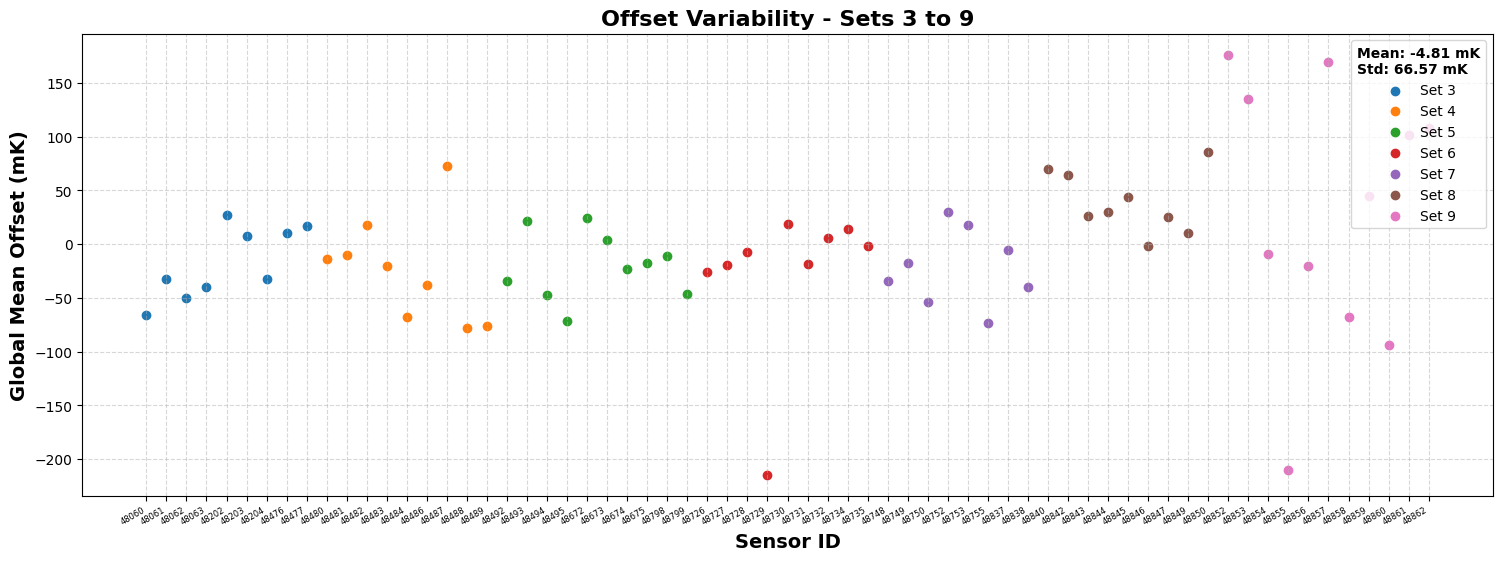

Set 10: len sensor_names=11, len global_means=11
  First sensor_name: '48864' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(510.161061460056) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 11: len sensor_names=11, len global_means=11
  First sensor_name: '48876' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(474.5711616109265) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 12: len sensor_names=11, len global_means=11
  First sensor_name: '48888' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-41.90747332782698) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 13: len sensor_names=11, len global_means=11
  First sensor_name: '48900' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-492.16611675545056) (type: <class 'numpy.float64'>)
  All global_mean types

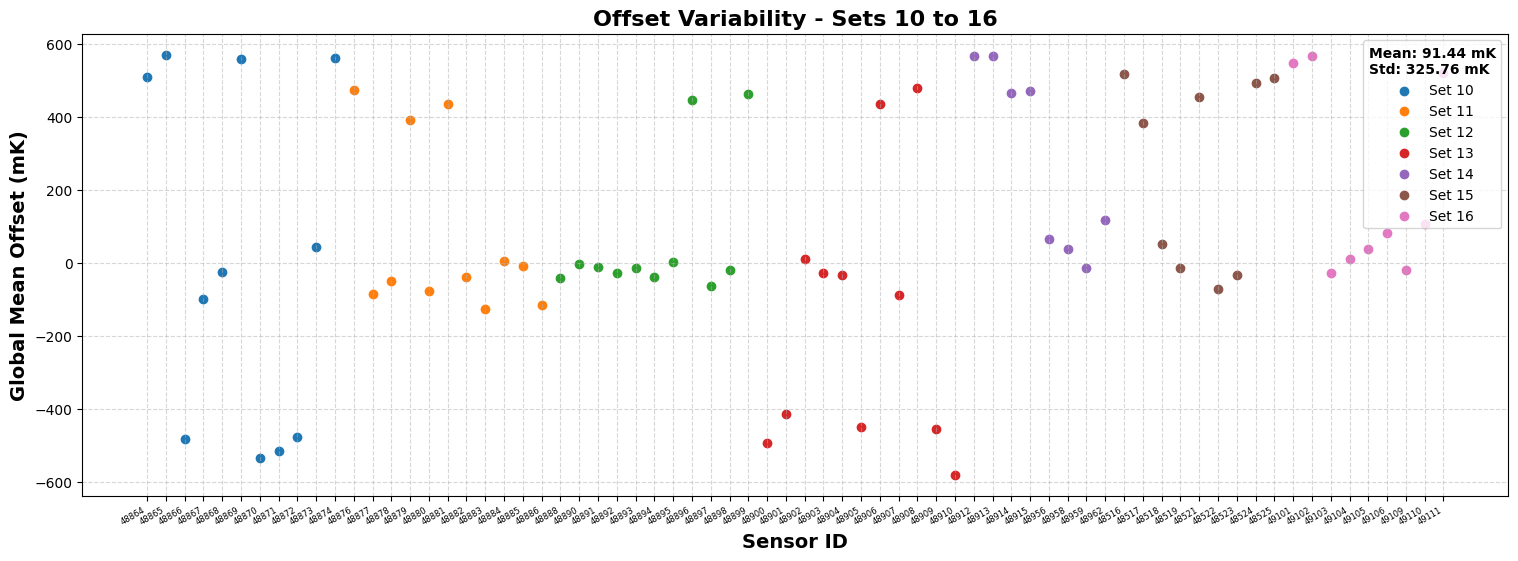

Set 17: len sensor_names=9, len global_means=9
  First sensor_name: '49113' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-402.586976713226) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 18: len sensor_names=10, len global_means=10
  First sensor_name: '49125' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(46.25990699789376) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 19: len sensor_names=10, len global_means=10
  First sensor_name: '49167' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-23.077077230149744) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 20: len sensor_names=11, len global_means=11
  First sensor_name: '49179' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-22.876541138700684) (type: <class 'numpy.float64'>)
  All global_mean types

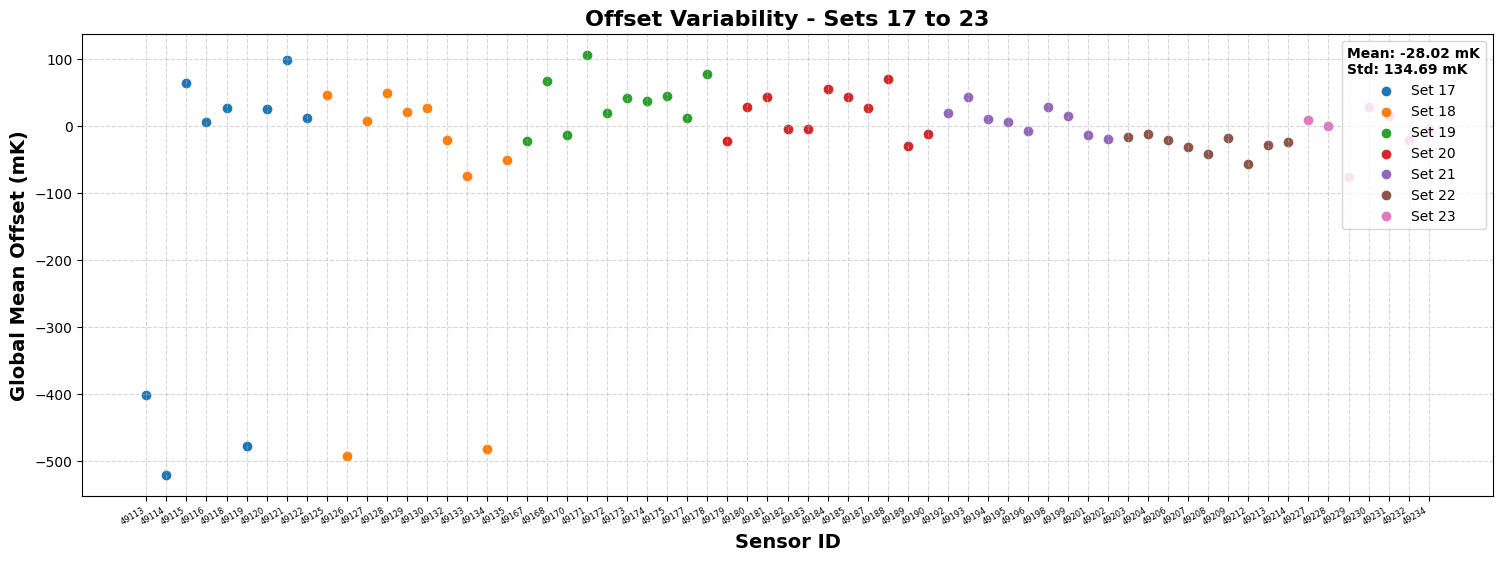

Set 24: len sensor_names=10, len global_means=10
  First sensor_name: '49238' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(43.43578343792494) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 25: len sensor_names=9, len global_means=9
  First sensor_name: '49250' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(5.353061249734044) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 26: len sensor_names=8, len global_means=8
  First sensor_name: '55069' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-75.36147611951102) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 27: len sensor_names=8, len global_means=8
  First sensor_name: '54880' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(18.509297143718772) (type: <class 'numpy.float64'>)
  All global_mean types: {'fl

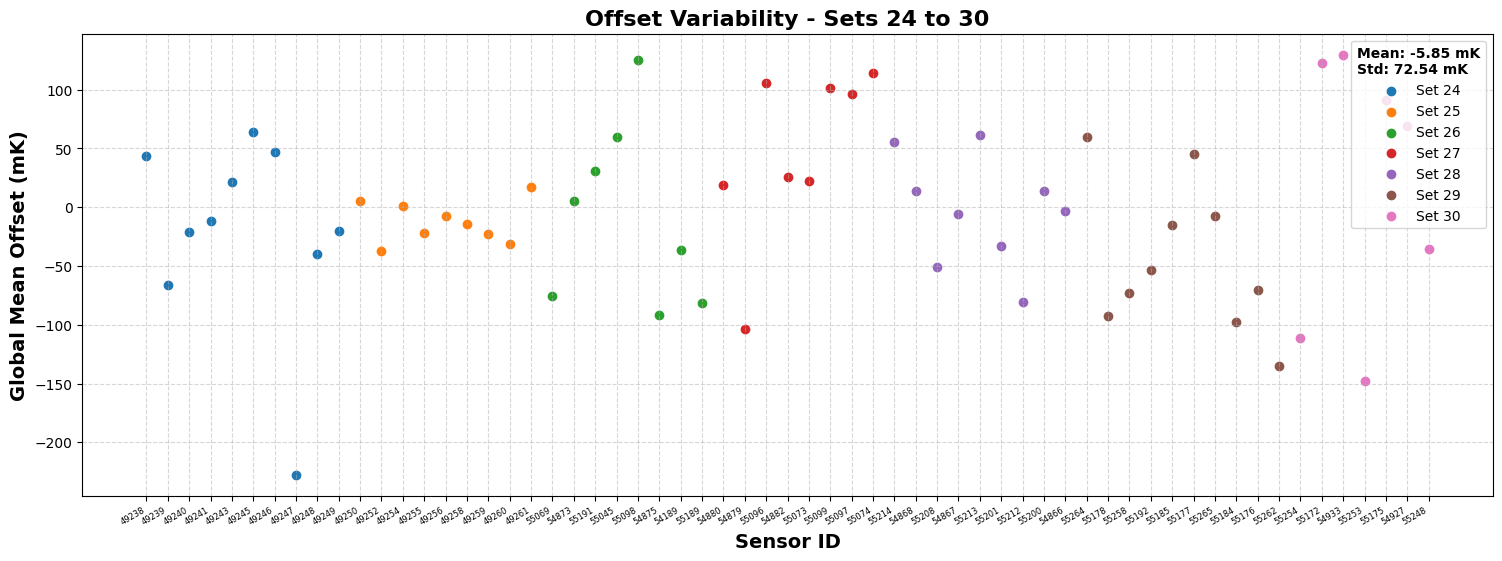

Set 31: len sensor_names=10, len global_means=10
  First sensor_name: '55179' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(229.39273056790006) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 32: len sensor_names=10, len global_means=10
  First sensor_name: '55247' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-43.748213067542714) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 33: len sensor_names=10, len global_means=10
  First sensor_name: '55167' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-94.67676104083002) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 34: len sensor_names=11, len global_means=11
  First sensor_name: '54878' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(20.90902421148625) (type: <class 'numpy.float64'>)
  All global_mean typ

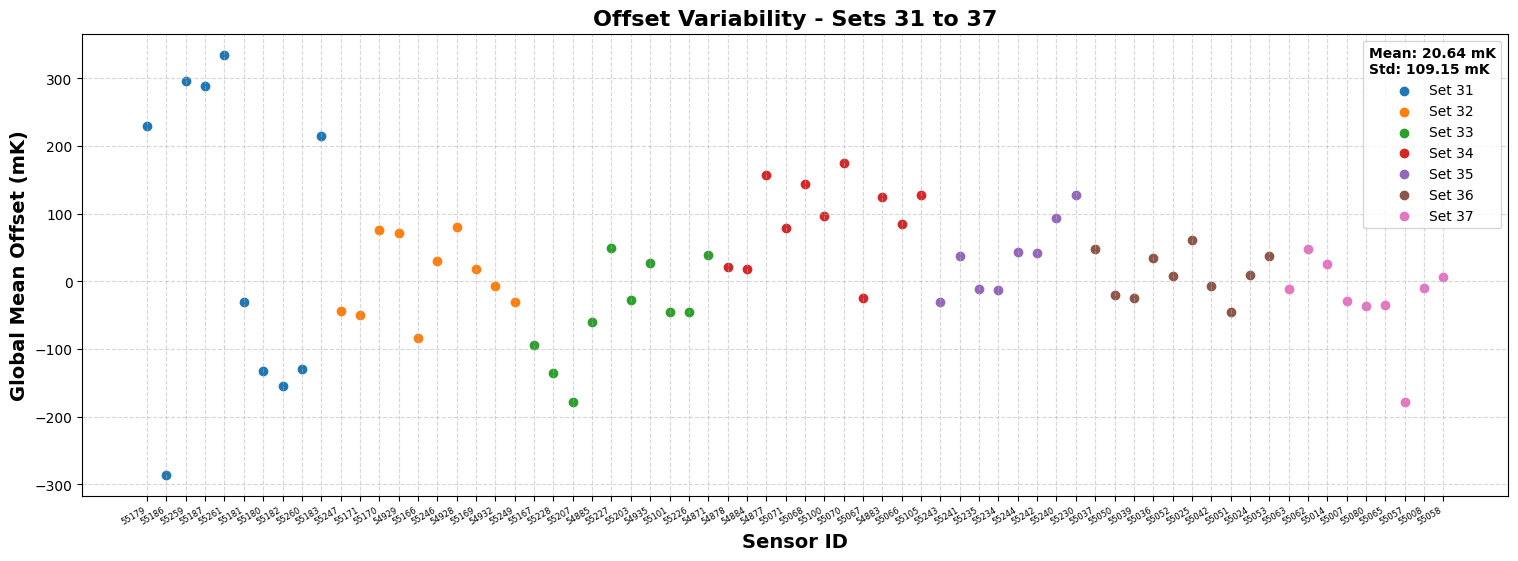

Set 38: len sensor_names=10, len global_means=10
  First sensor_name: '55218' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(35.93507613274094) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 39: len sensor_names=11, len global_means=11
  First sensor_name: '55238' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(102.02864675880144) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 40: len sensor_names=10, len global_means=10
  First sensor_name: '55206' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(96.61793022956275) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 41: len sensor_names=11, len global_means=11
  First sensor_name: '54896' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(746.1446600075965) (type: <class 'numpy.float64'>)
  All global_mean types:

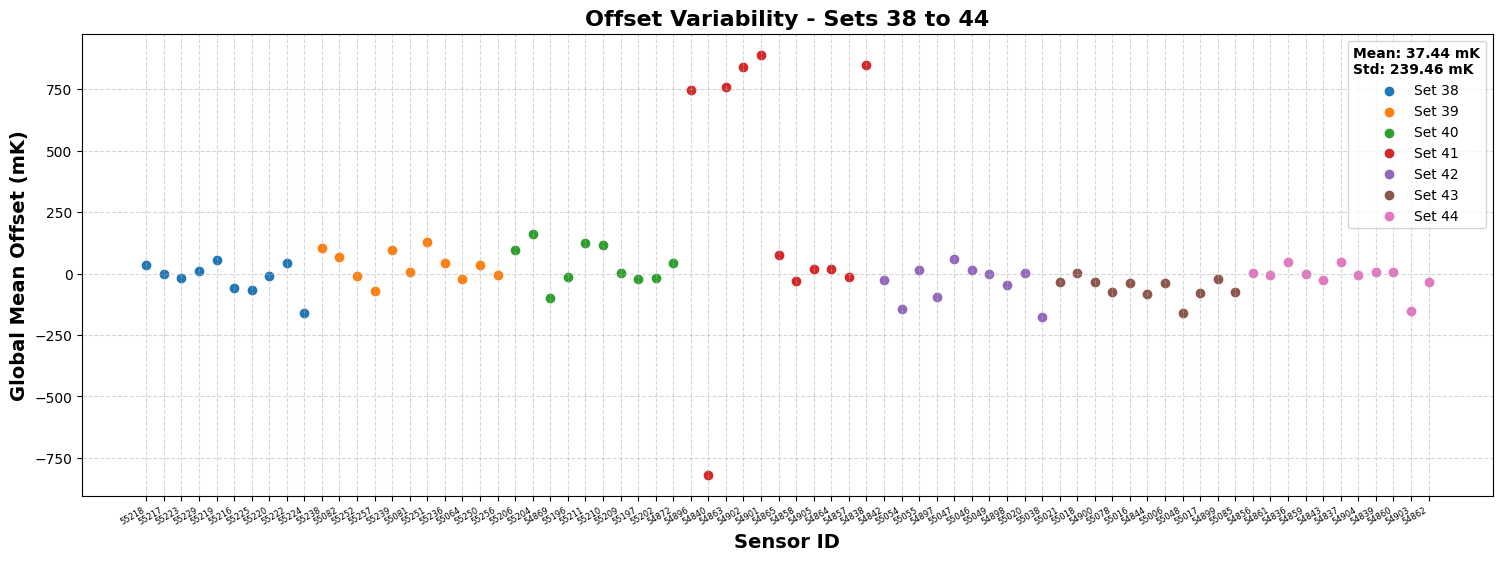

Set 45: len sensor_names=11, len global_means=11
  First sensor_name: '55056' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-12.841195984016062) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 46: len sensor_names=10, len global_means=10
  First sensor_name: '48957' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-593.6558416578946) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 47: len sensor_names=10, len global_means=10
  First sensor_name: '55190' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(3.777899346017095) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 48: len sensor_names=10, len global_means=10
  First sensor_name: '55231' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(162.17944770715914) (type: <class 'numpy.float64'>)
  All global_mean typ

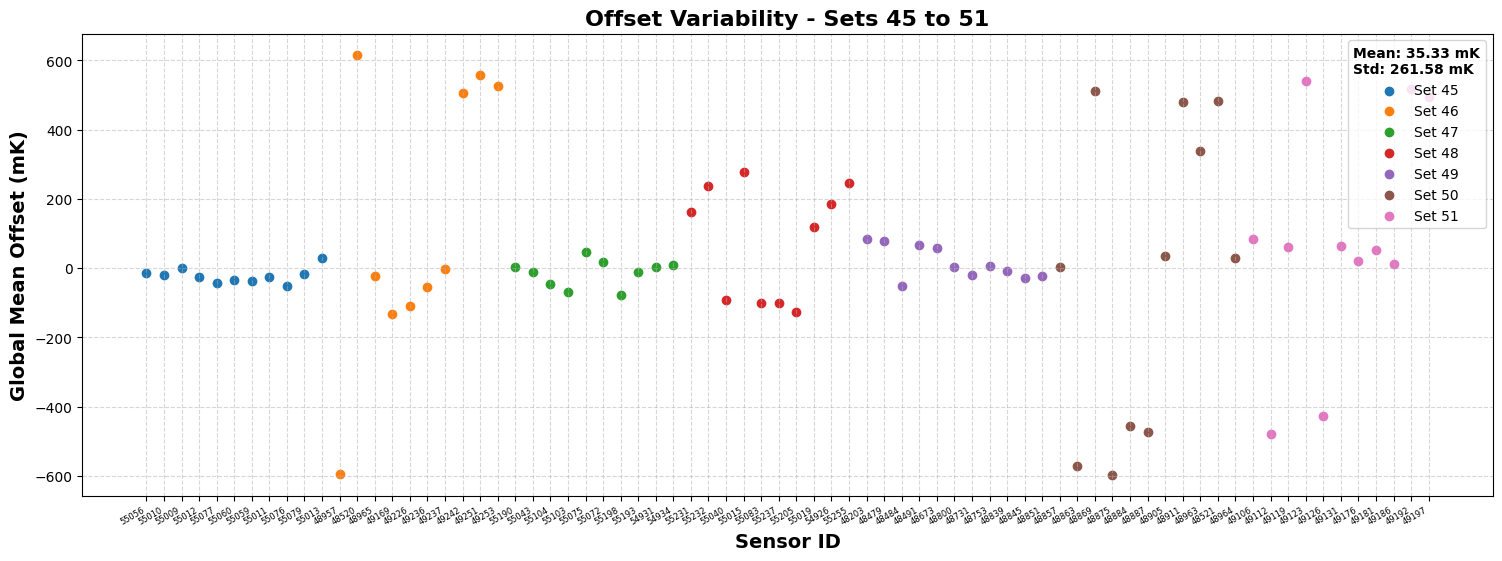

Set 52: len sensor_names=11, len global_means=11
  First sensor_name: '49204' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(557.4797904736711) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 53: len sensor_names=11, len global_means=11
  First sensor_name: '55186' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-131.34363181686157) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 54: len sensor_names=11, len global_means=11
  First sensor_name: '54876' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-32.02924497802756) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 55: len sensor_names=11, len global_means=11
  First sensor_name: '54869' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-95.87204610846507) (type: <class 'numpy.float64'>)
  All global_mean typ

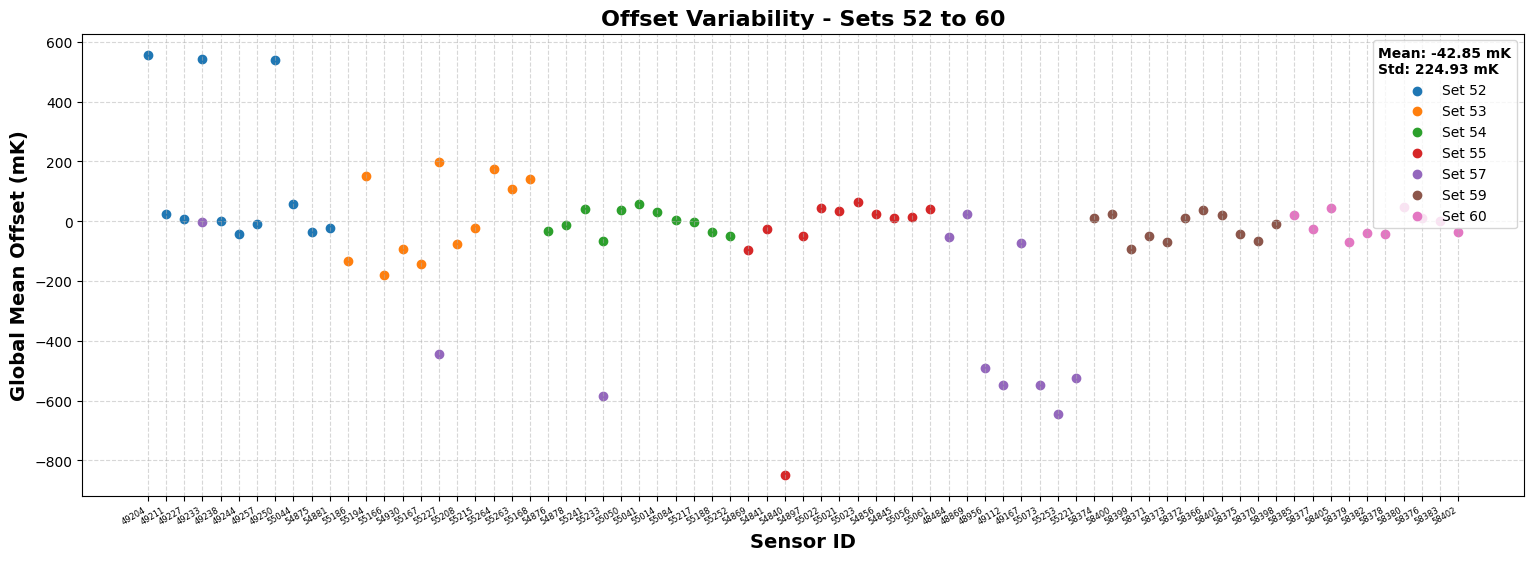

In [2]:
# 9. Plot the global mean of offsets per sensor
set_instance.plot_global_means(selected_sets=selected_sets)
# set_instance.plot_global_means()

Processing 56 sets.


/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/src/set.py:1567: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=legend_title, title_fontproperties={'weight': 'bold'}, loc='upper left')


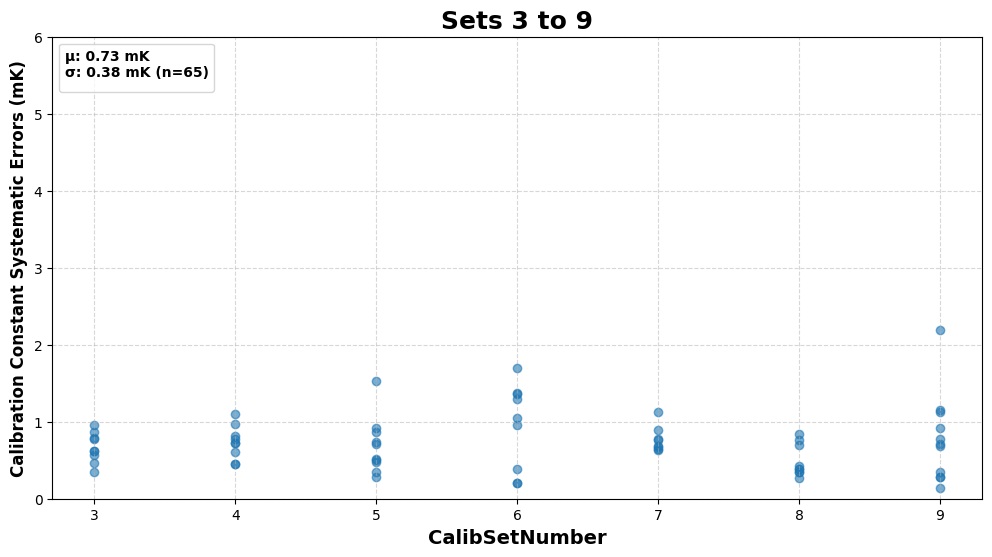

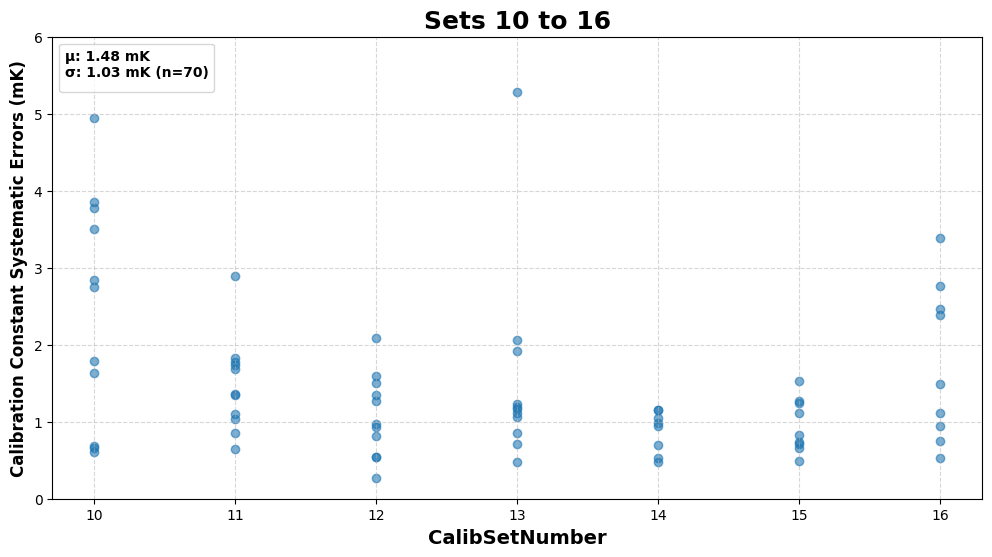

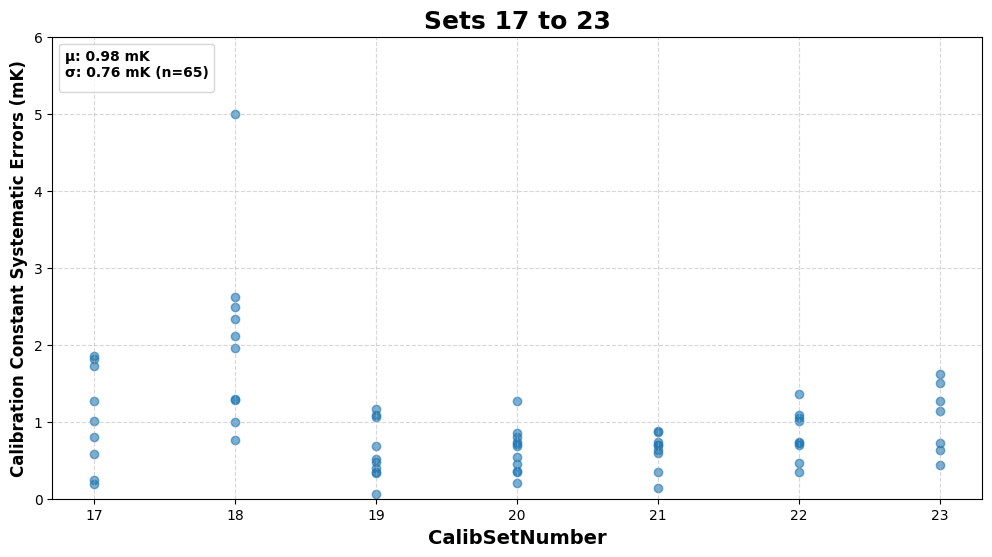

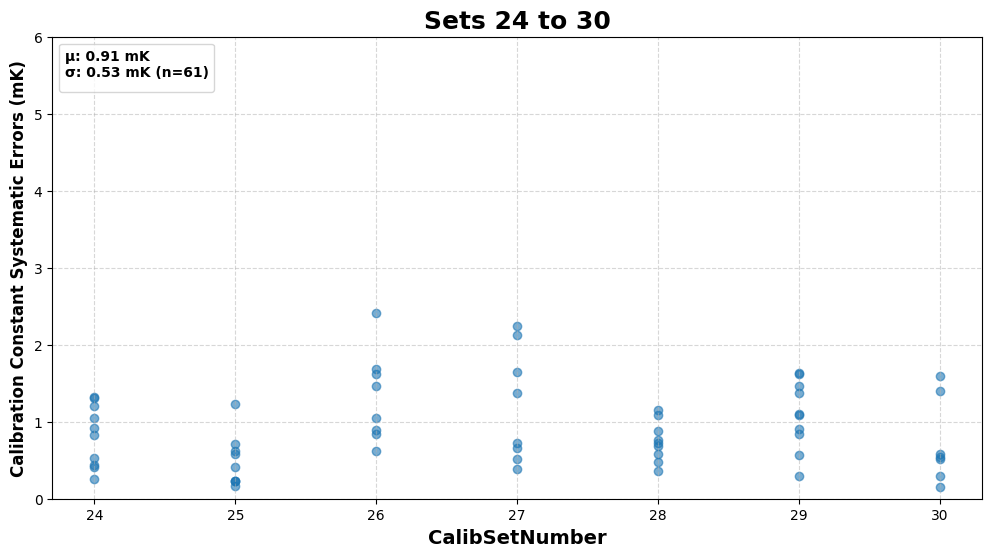

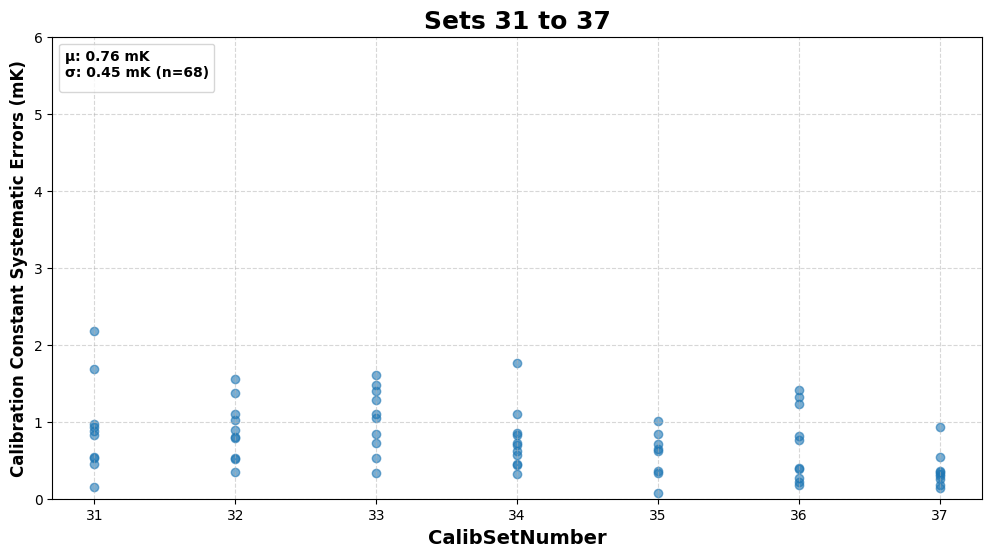

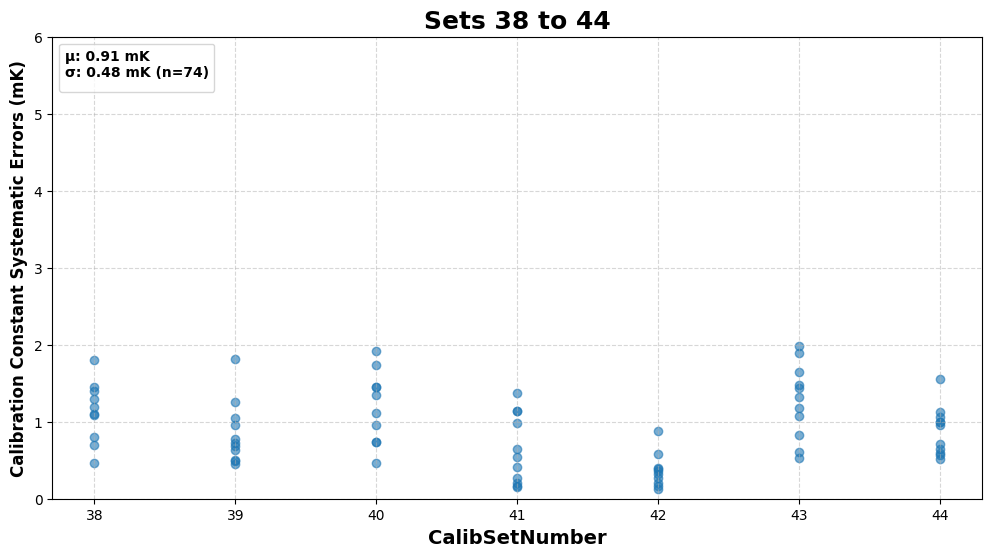

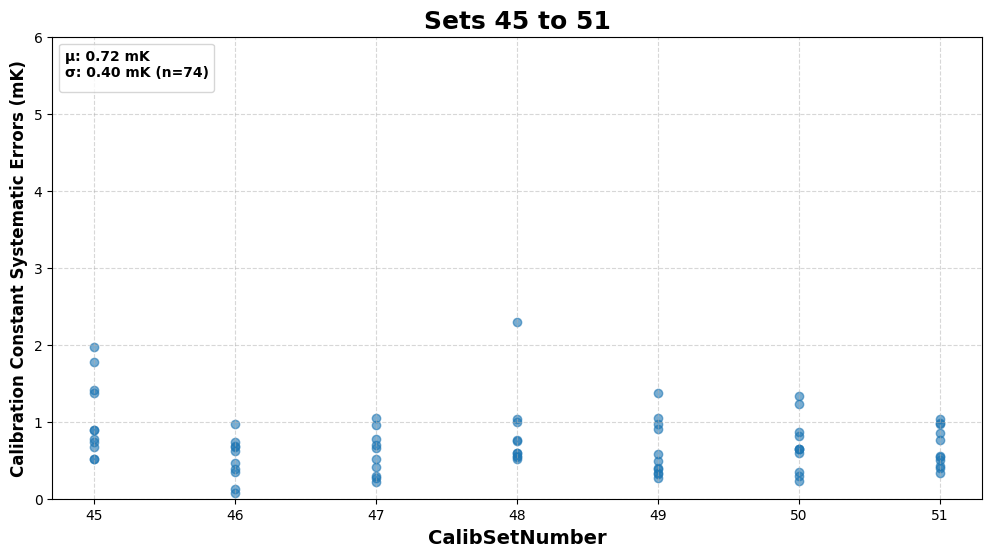

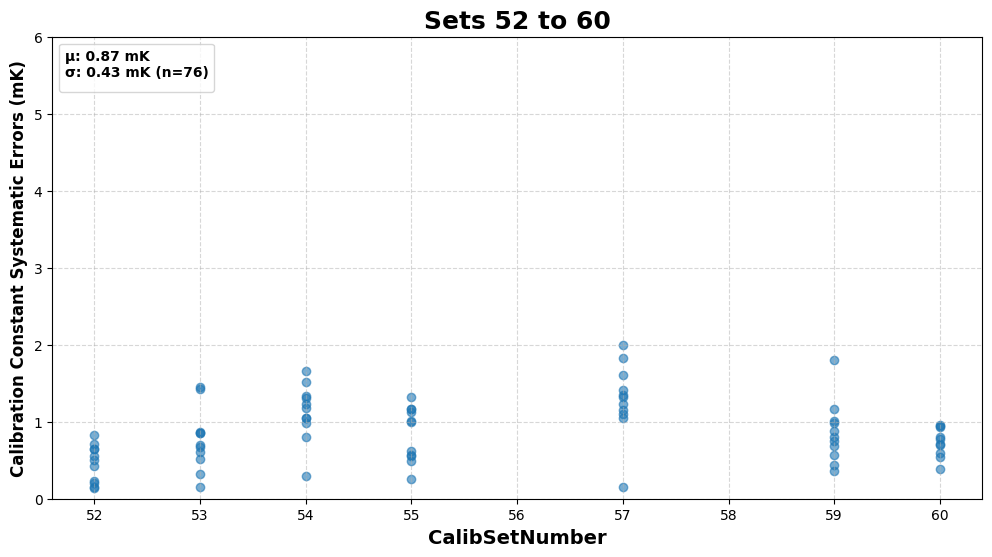

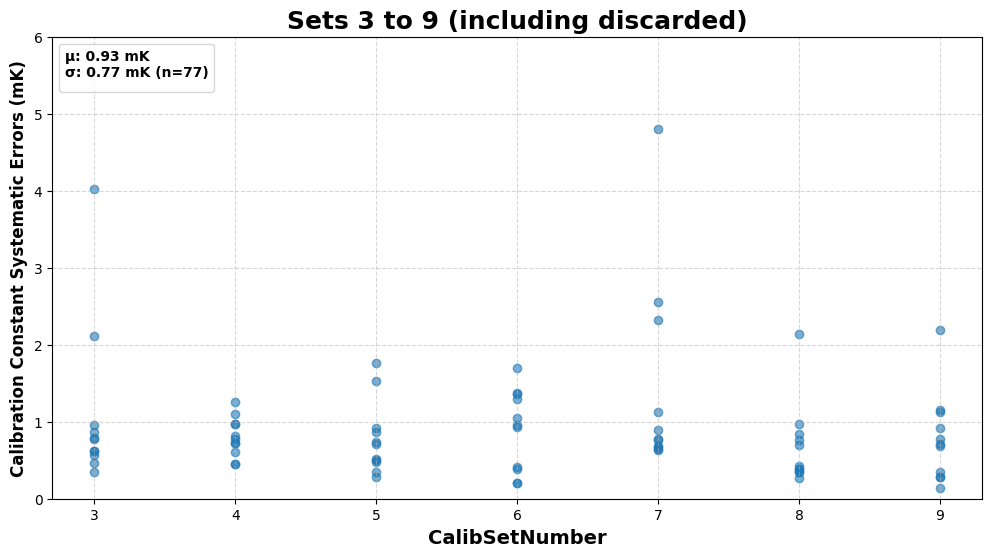

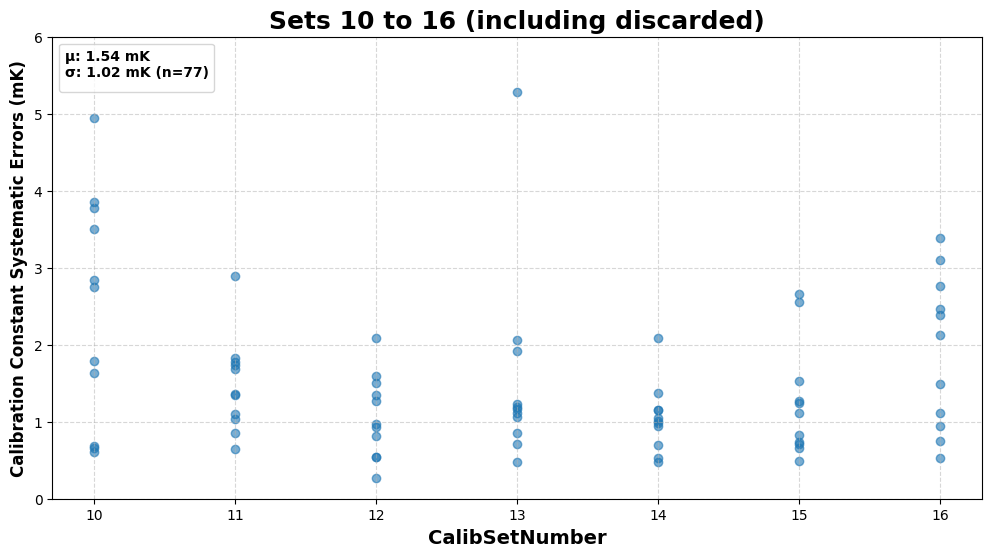

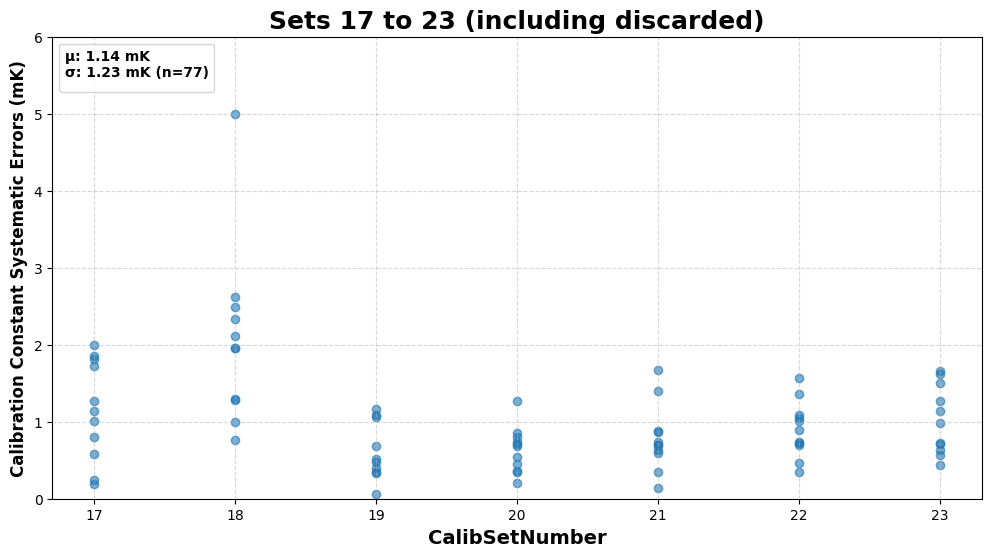

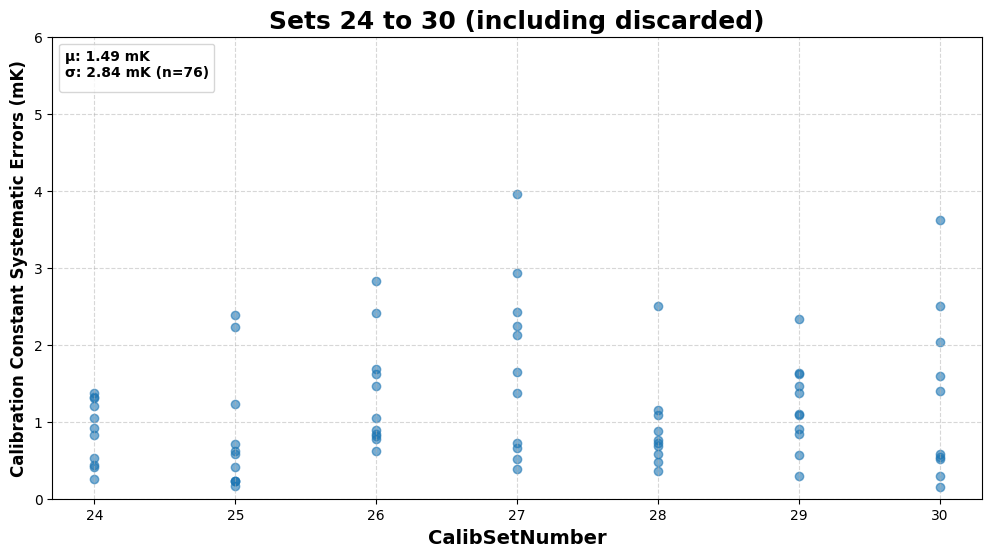

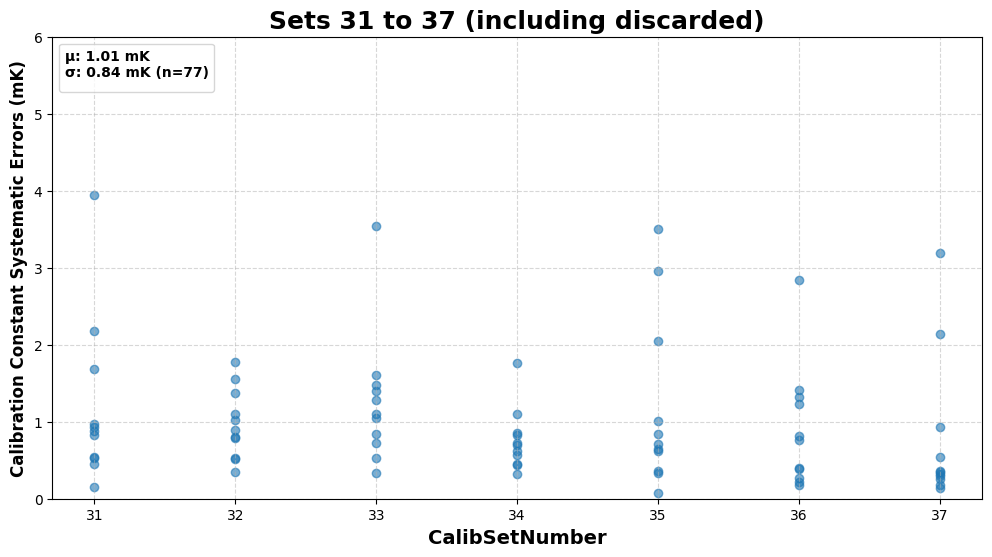

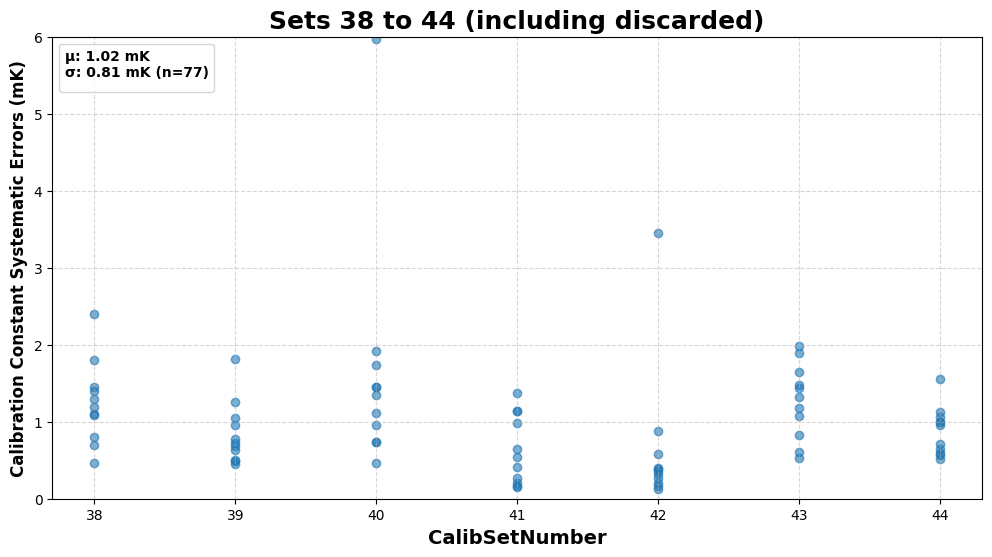

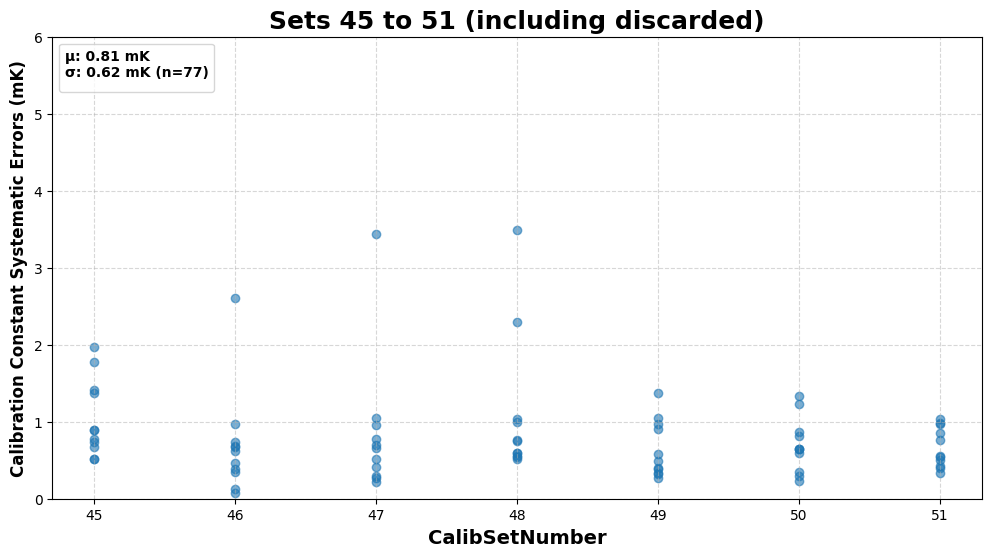

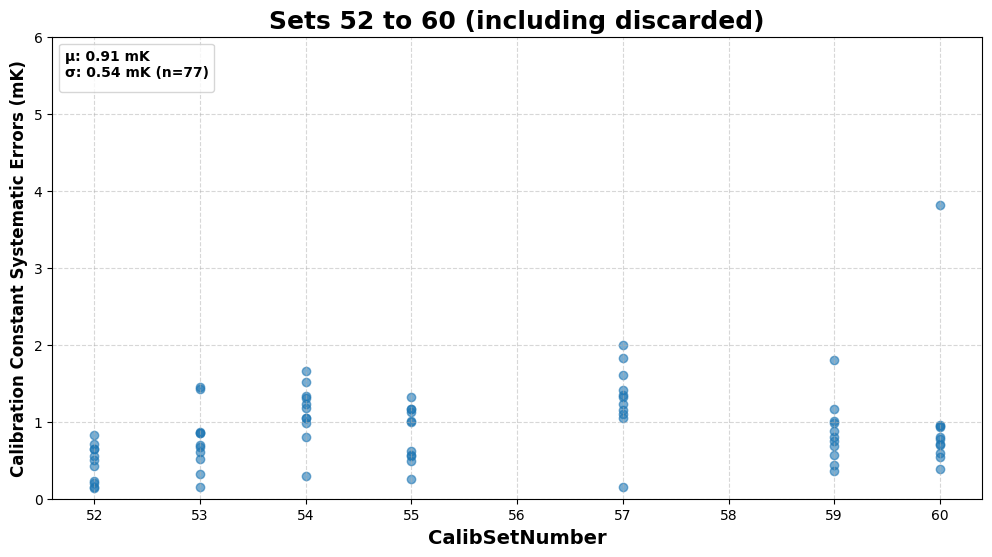

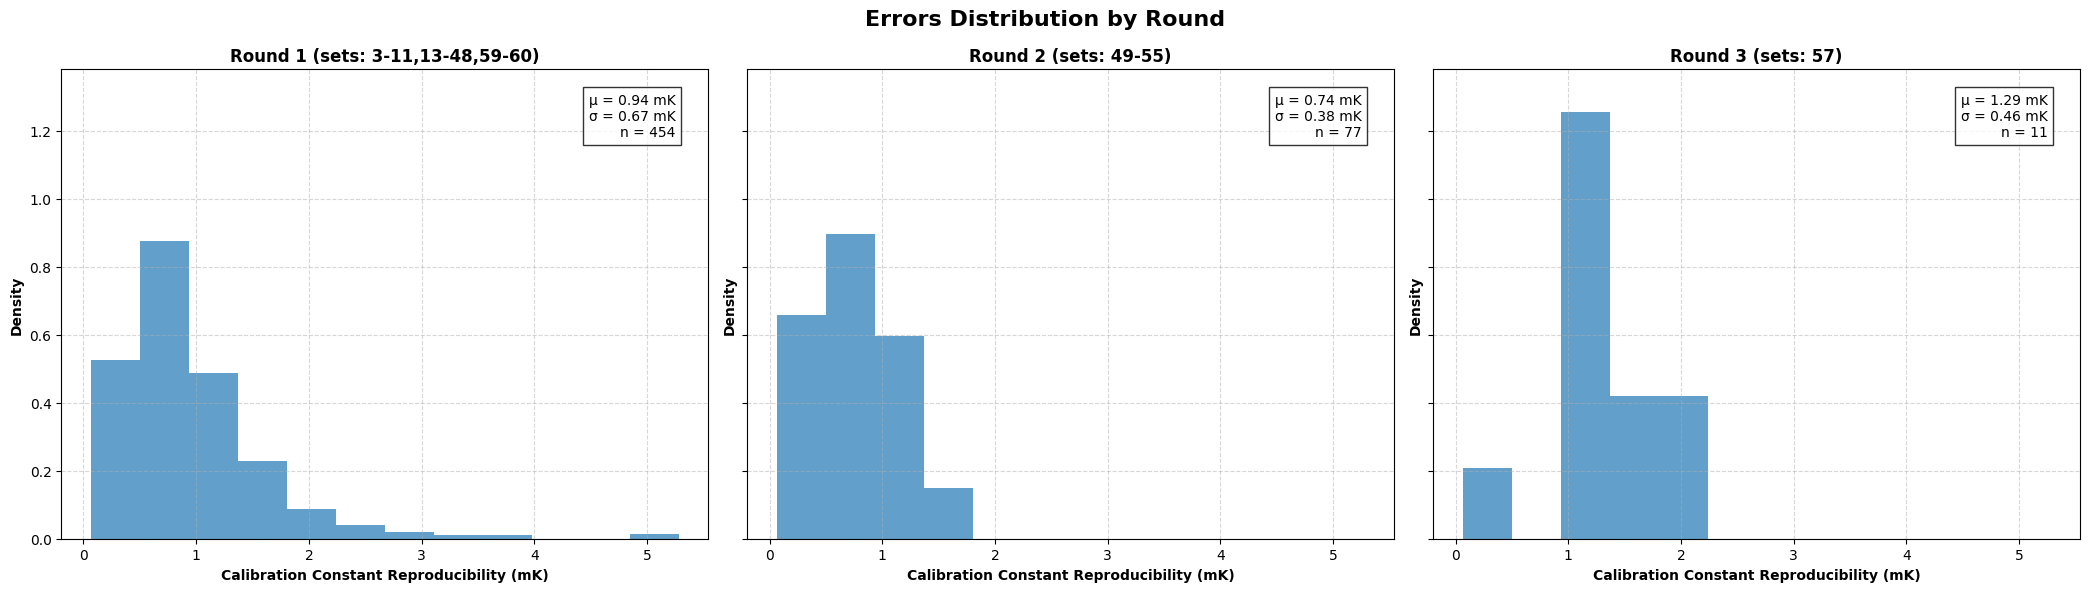

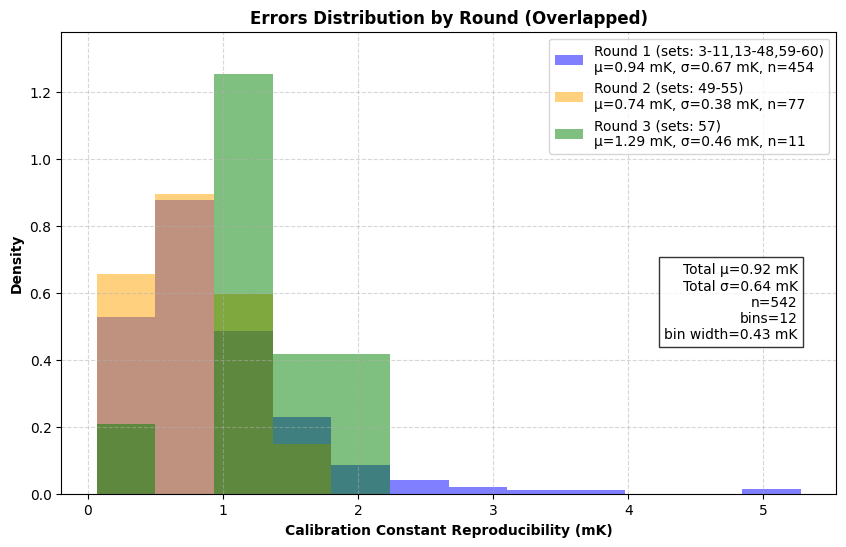

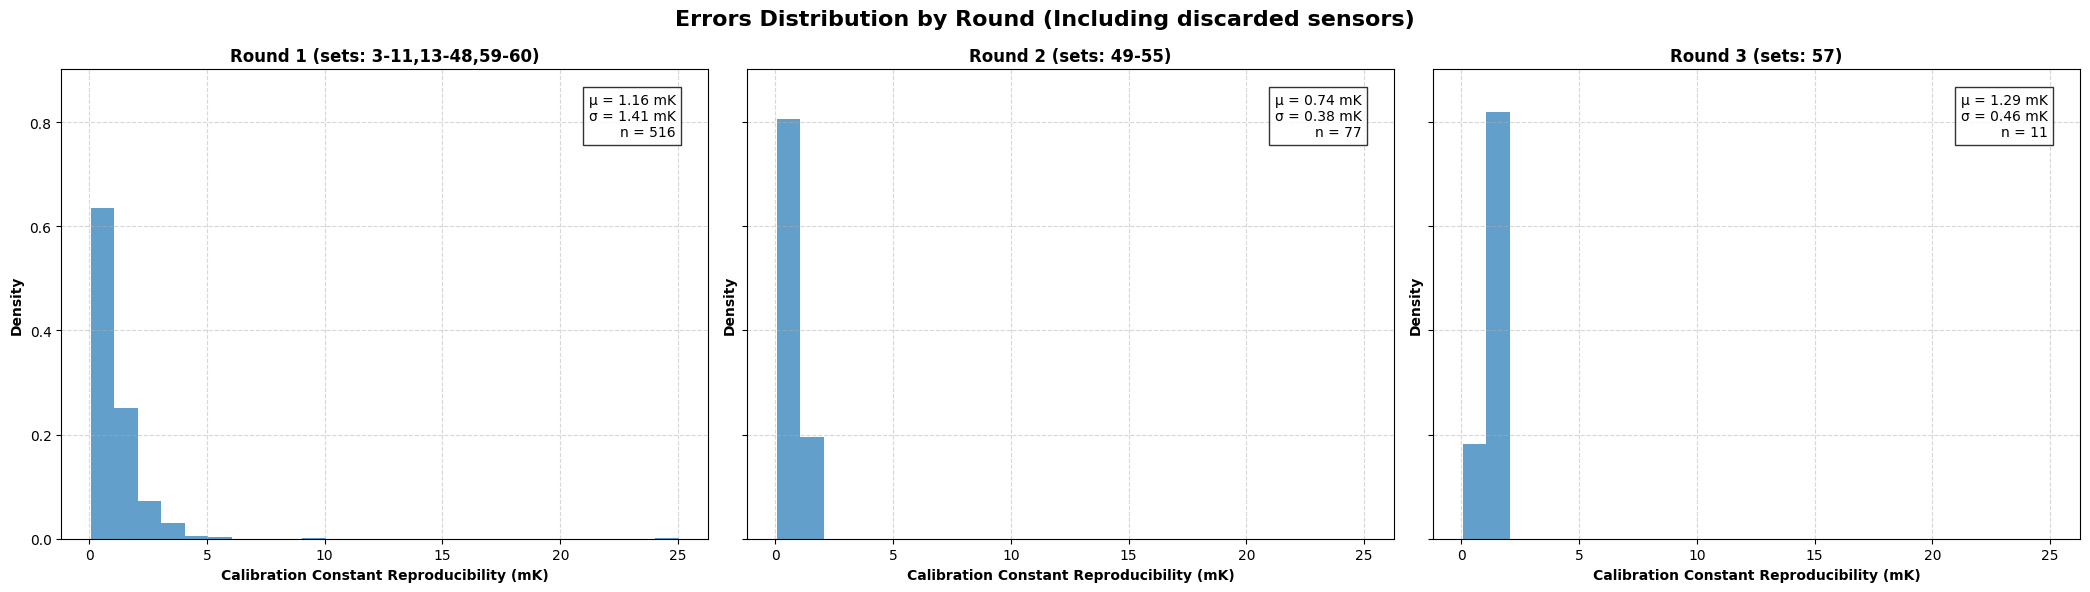

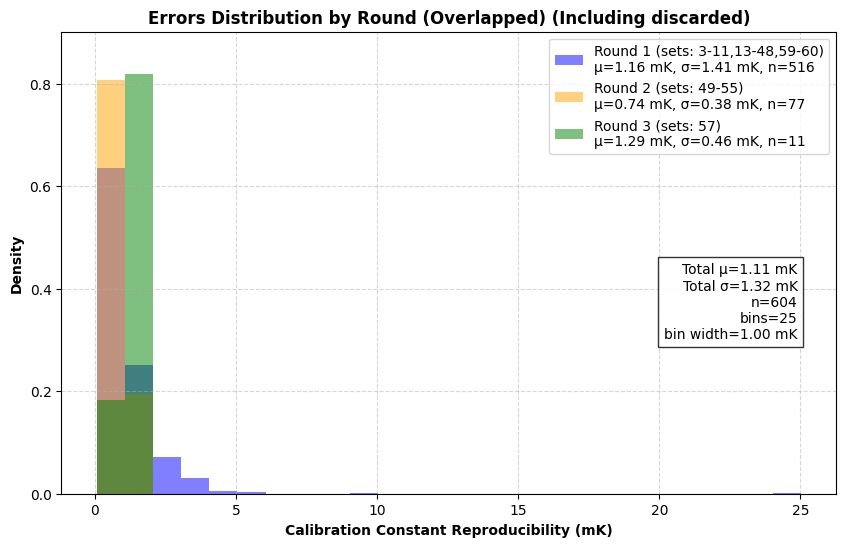

In [3]:
# 11. Generar histogramas por ronda con más bins
# Los histogramas incluyen:
# - Distribuciones por ronda (separadas y overlapped)
# - Comparación Round 1 vs Rounds 2+3 (overlapped)
# - Versiones con y sin sensores descartados (20 bins vs 12 bins)
set_instance.plot_global_sigmas(selected_sets=selected_sets, save_dir='outputs/histograms_by_round')

Processing 56 sets.


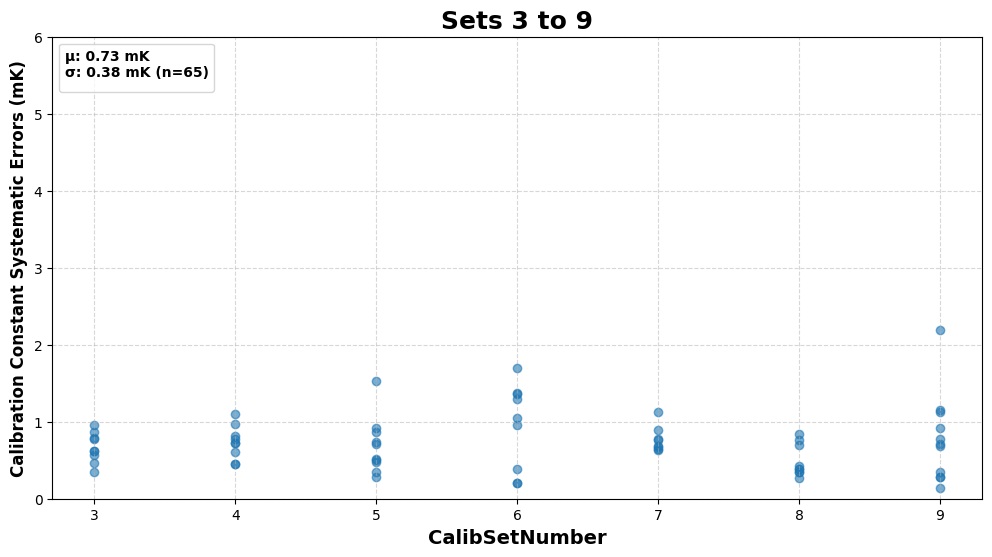

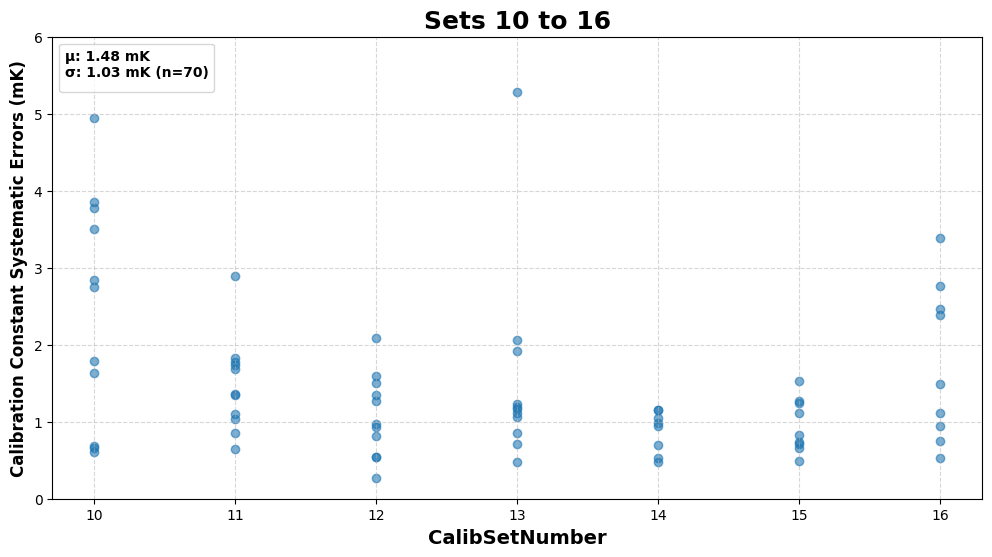

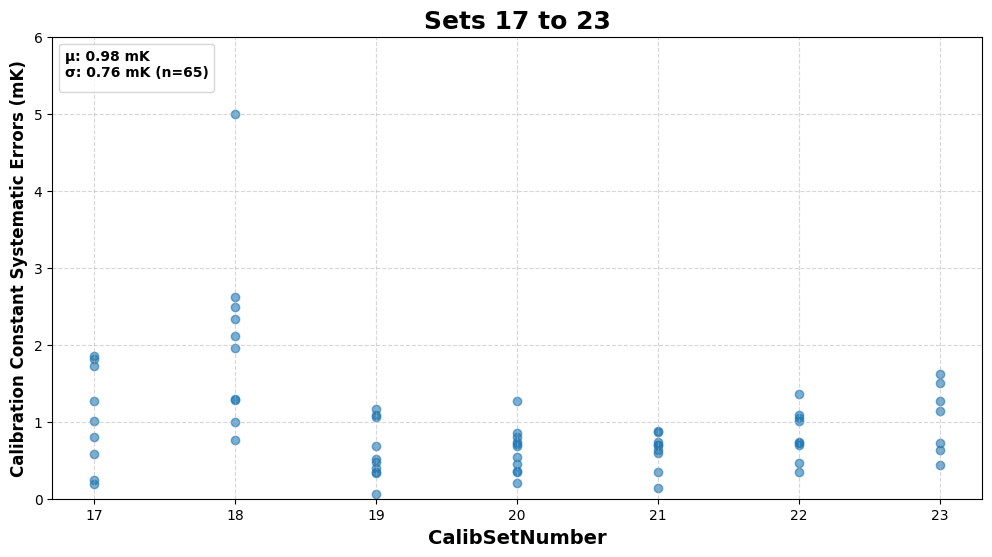

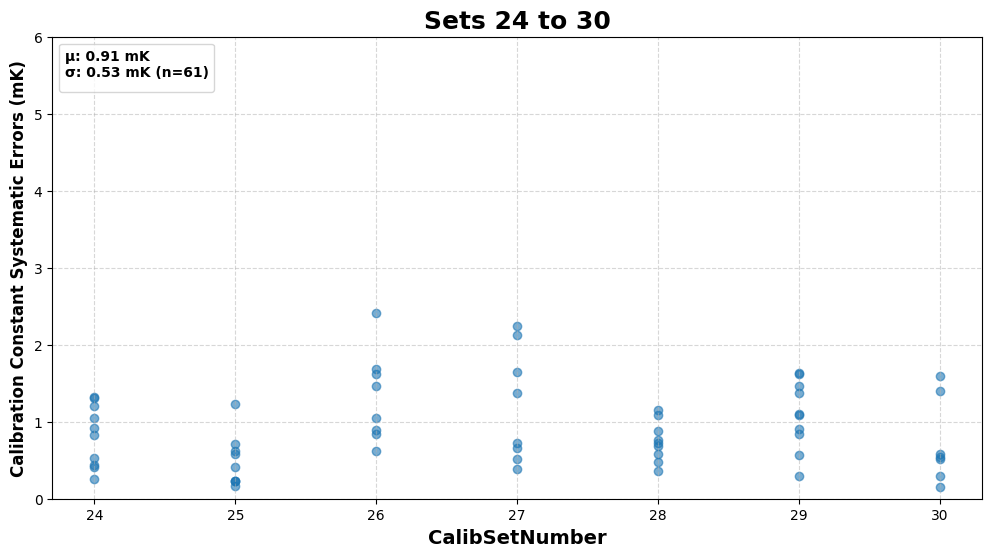

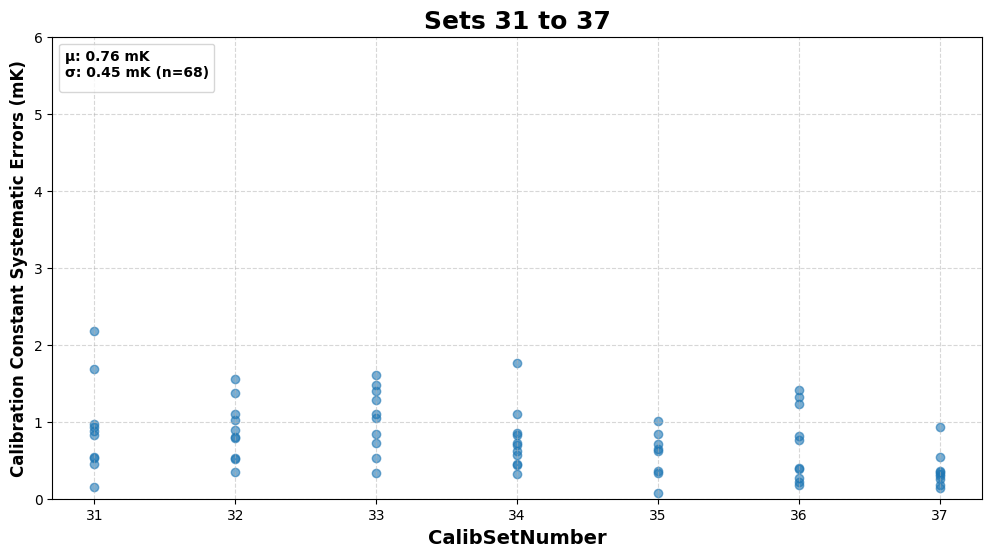

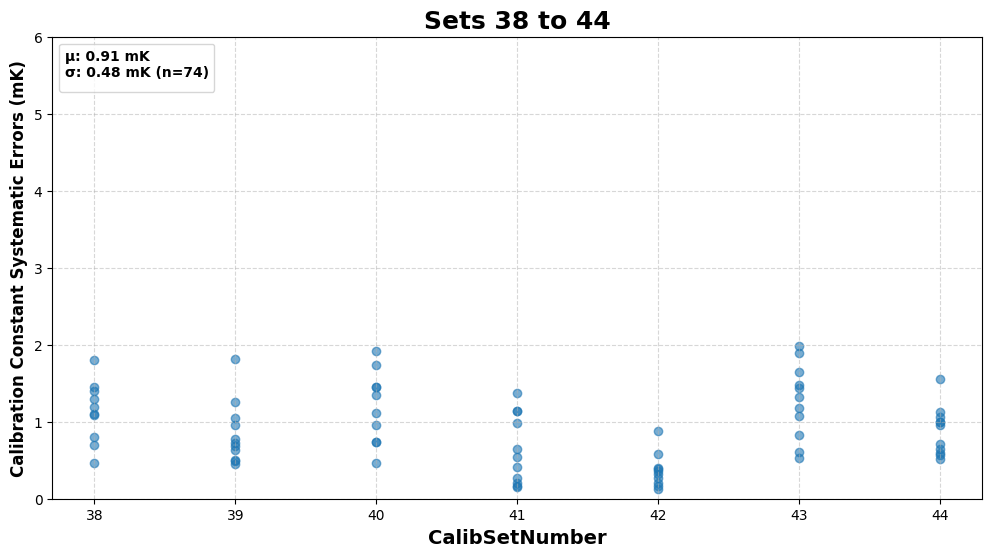

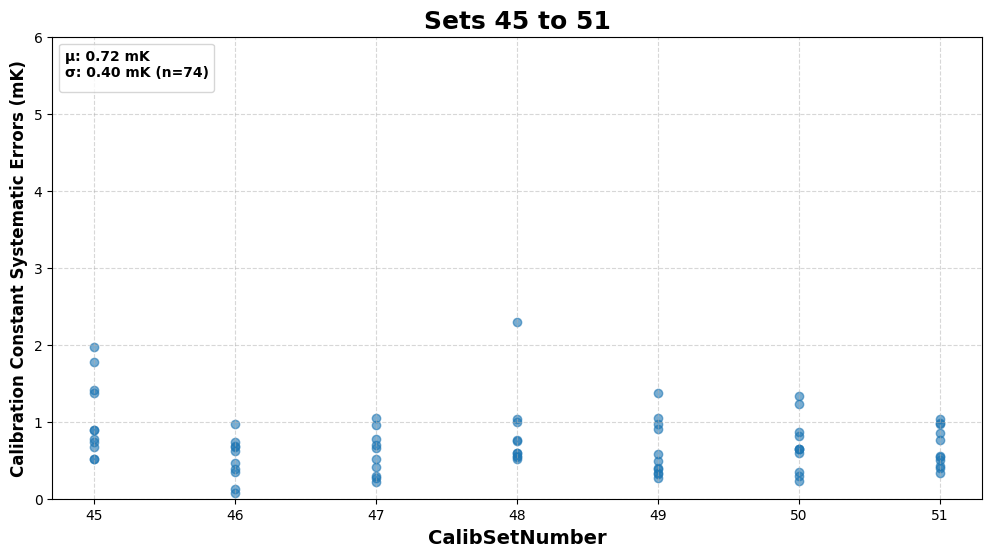

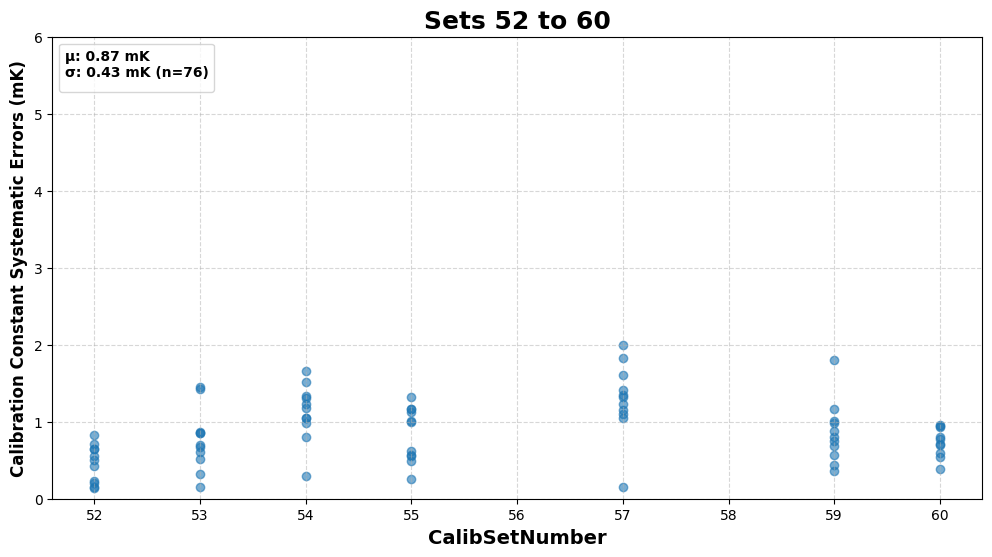

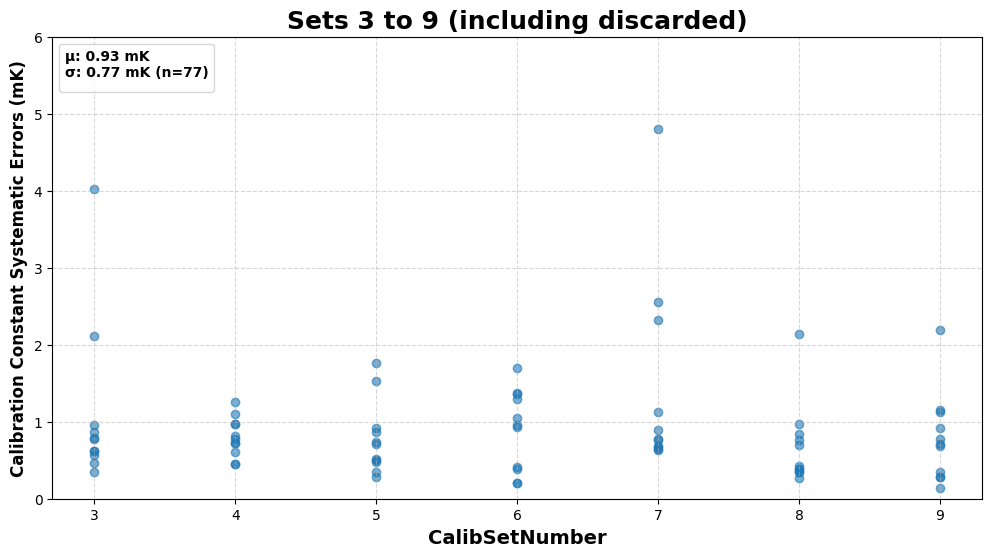

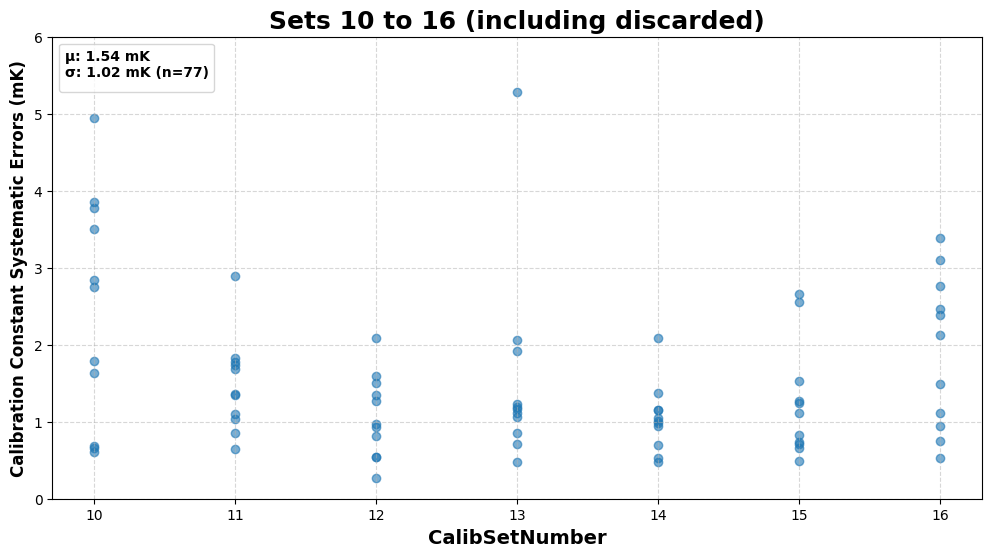

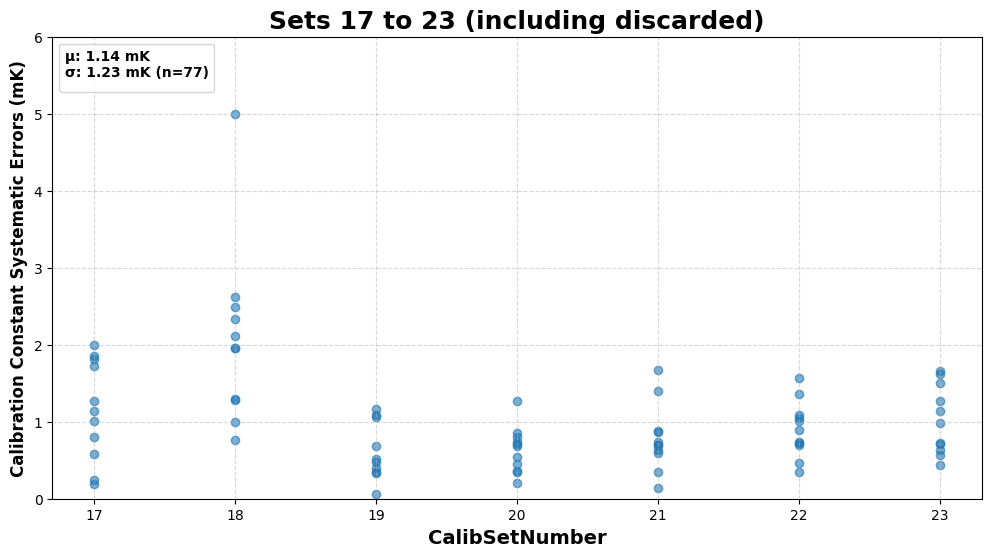

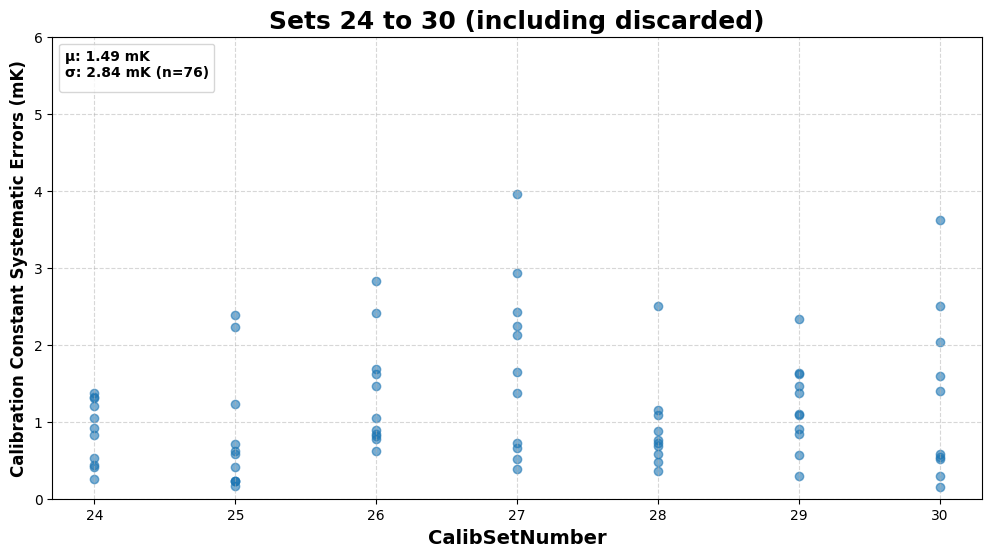

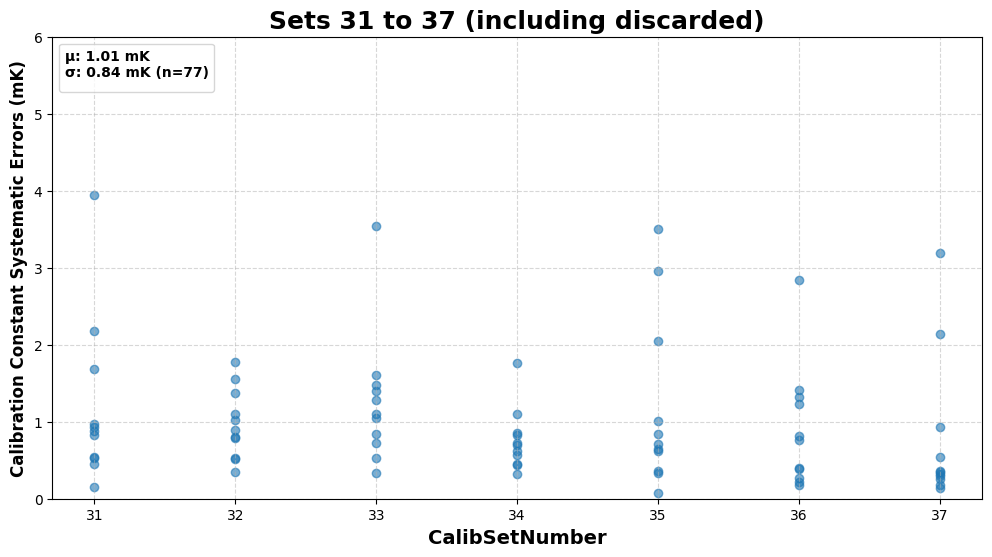

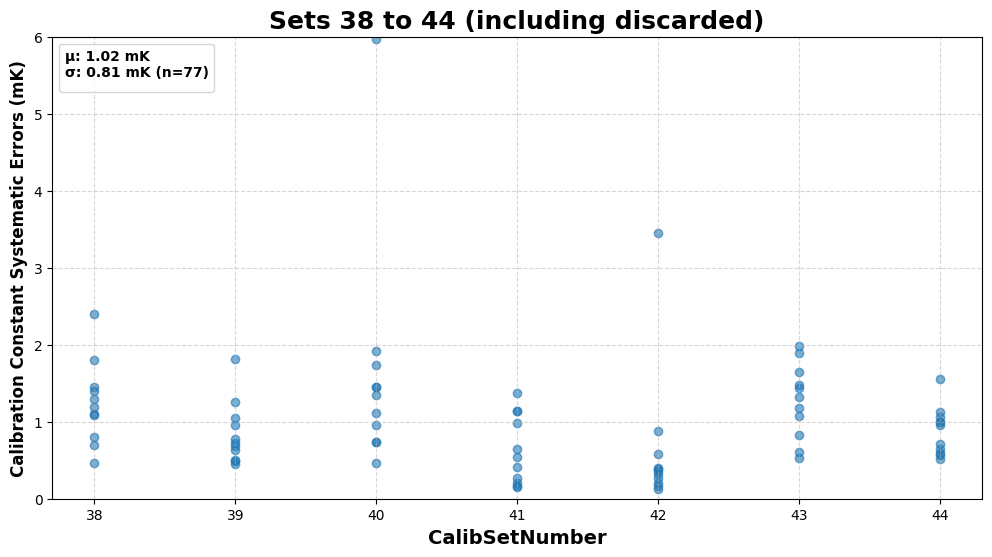

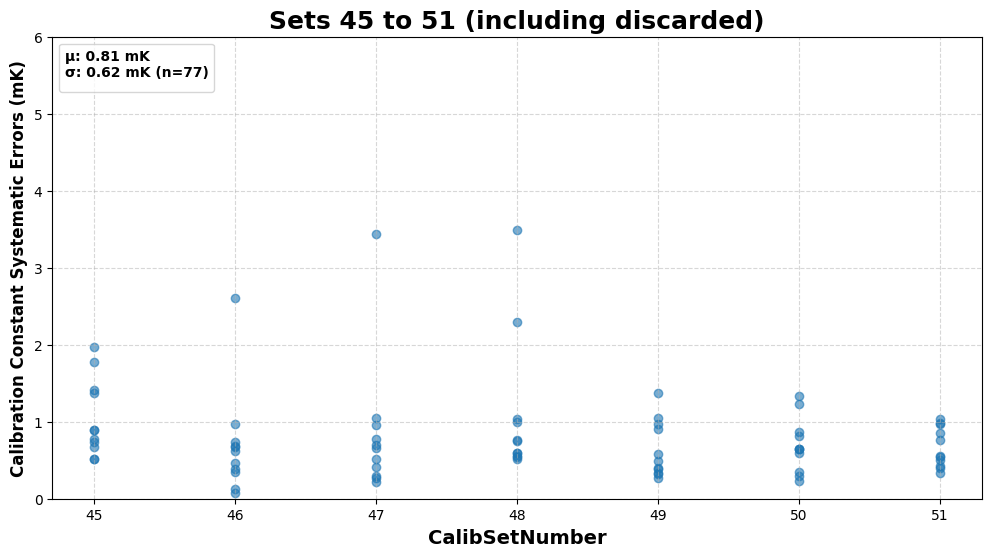

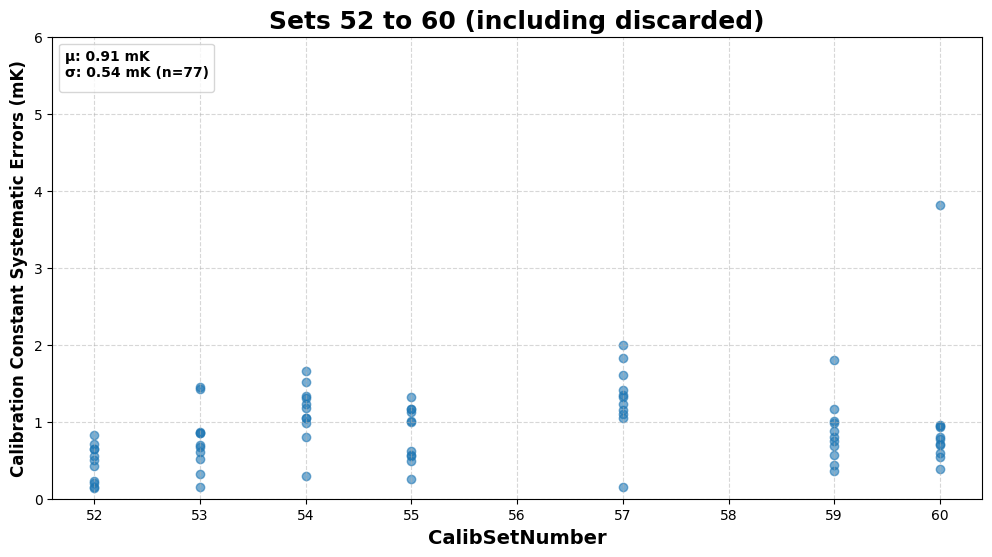

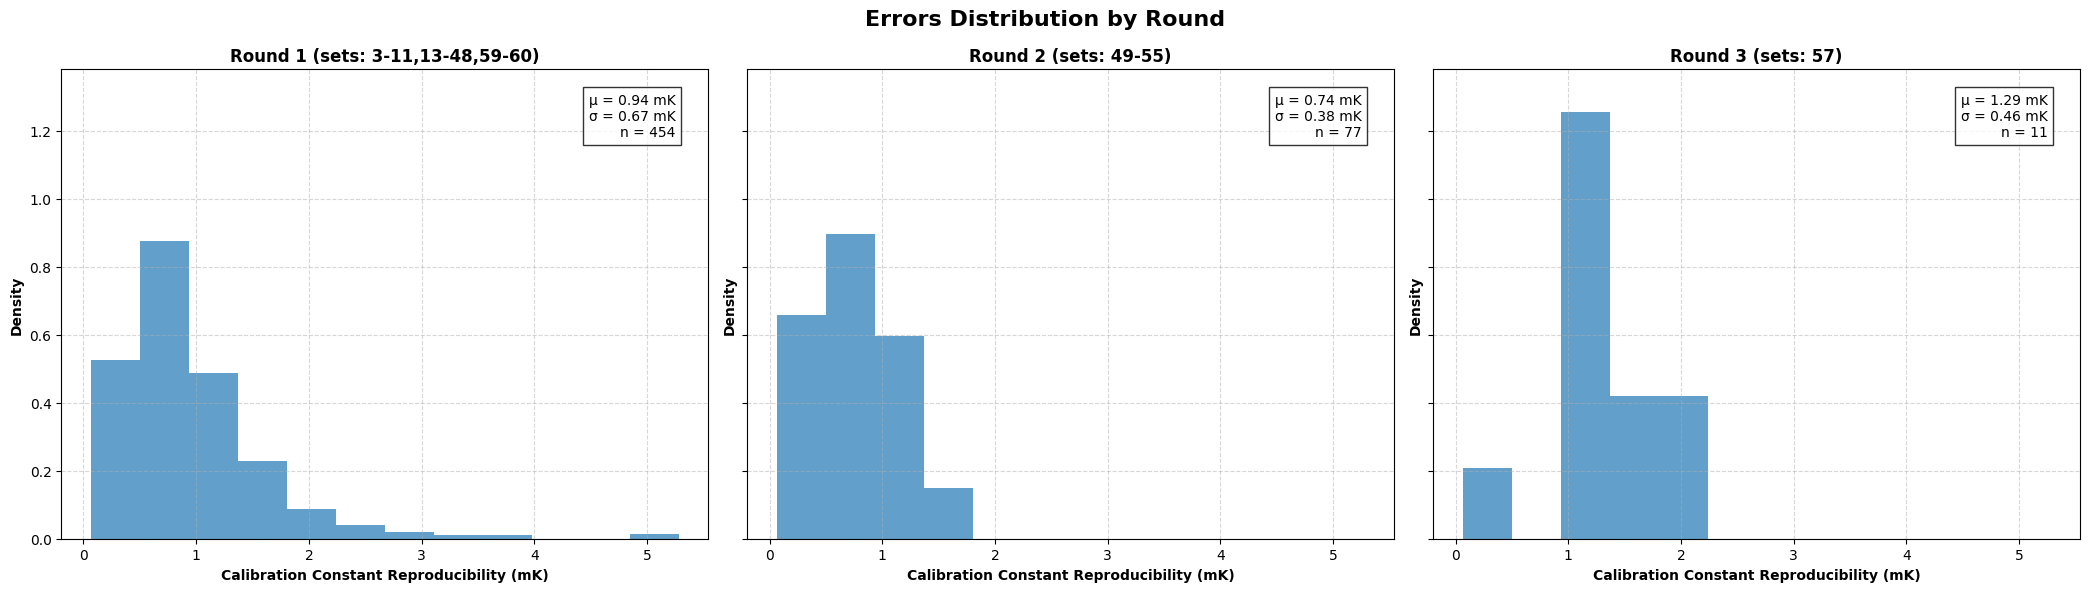

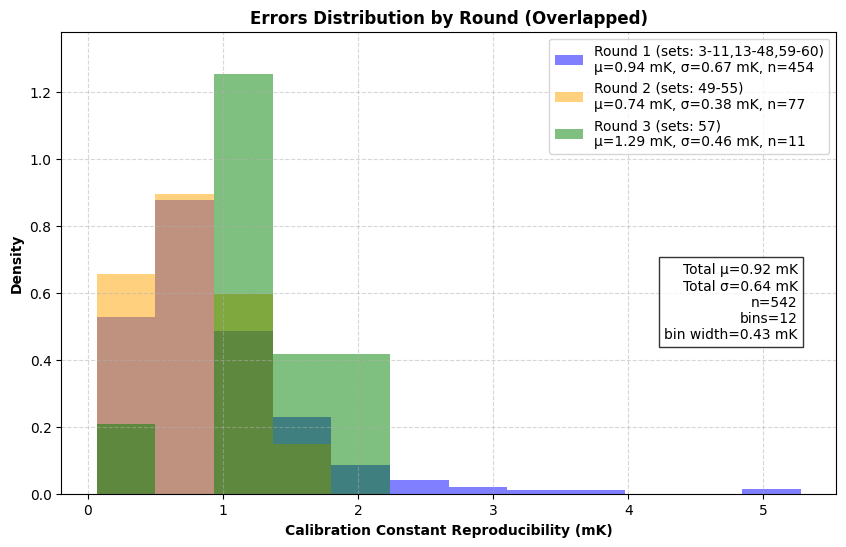

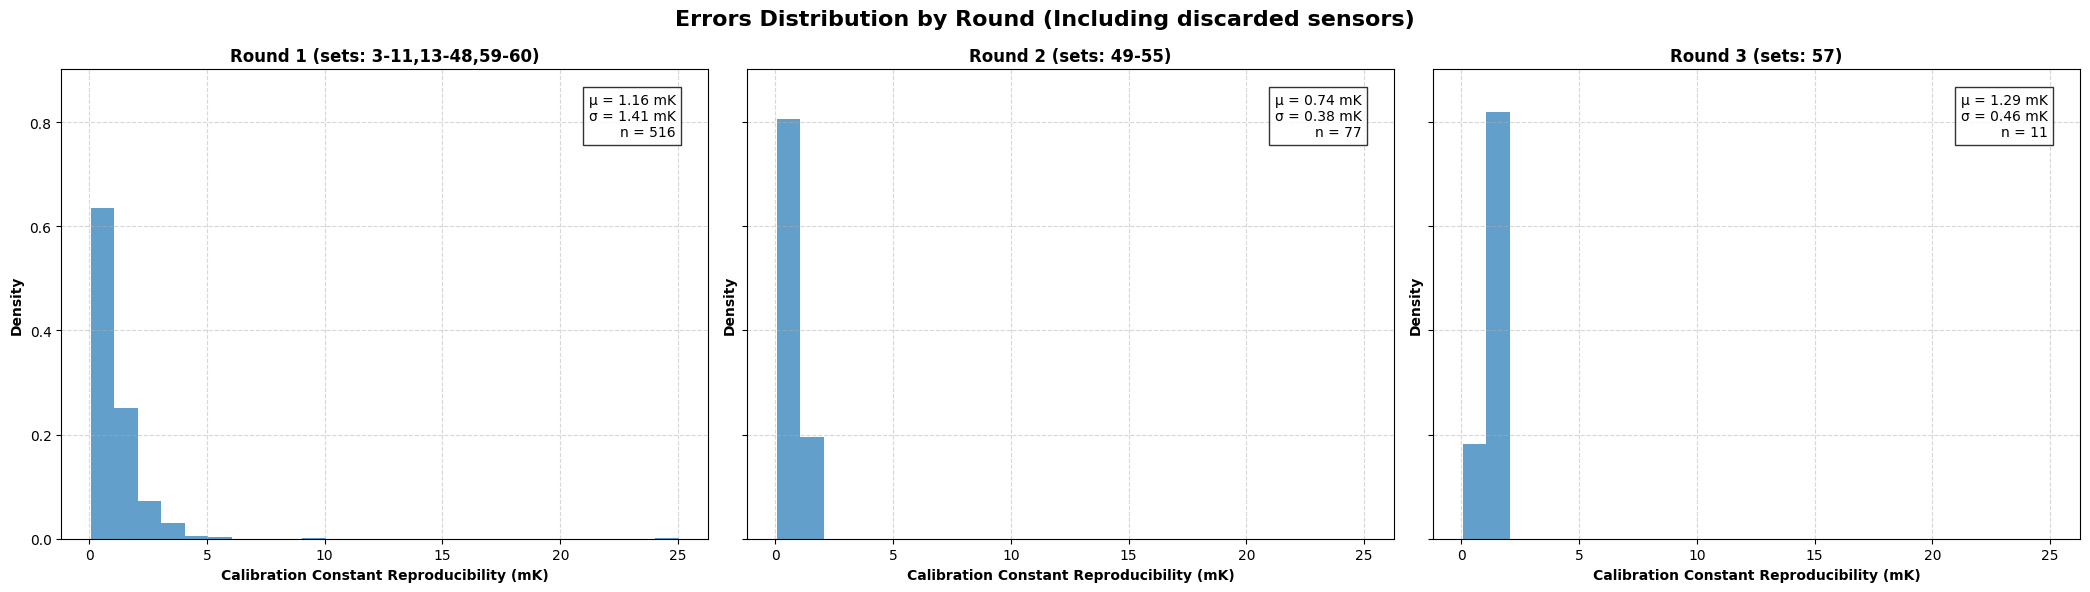

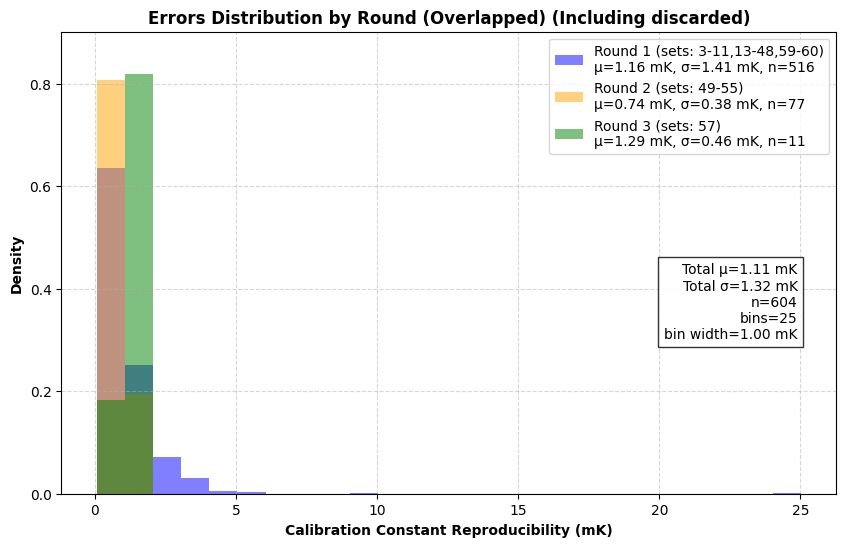

In [4]:
# 12. Generar histogramas adicionales por ronda (genera automáticamente versiones con y sin descartados)
# El método plot_global_sigmas() genera internamente dos versiones:
# - Una sin sensores descartados: "global_sigma_histogram_rounds_*.png"
# - Otra con todos los sensores: "global_sigma_histogram_rounds_all_sensors_*.png"
set_instance.plot_global_sigmas(
    selected_sets=selected_sets, 
    save_dir='outputs/histograms_by_round_additional'
)

## Histogramas de Distribución de Errores por Ronda

Los histogramas a continuación muestran:

1. **Distribución por ronda**: Subplots separados y gráficos overlapped para todas las rondas (1, 2, 3, 4)
2. **Comparación Round 1 vs Rounds 2+3**: Gráficos overlapped específicos para comparar la primera ronda contra las rondas de re-calibración
3. **Versiones con y sin sensores descartados**: 
   - Sin descartados: 12 bins
   - Con descartados: 20 bins (mayor resolución para ver distribución completa)

La información de rondas se carga desde `config.yml`.

HISTOGRAMAS INCLUYENDO SENSORES DESCARTADOS (all_sensors)

📊 Histograma Overlapped (con sensores descartados):


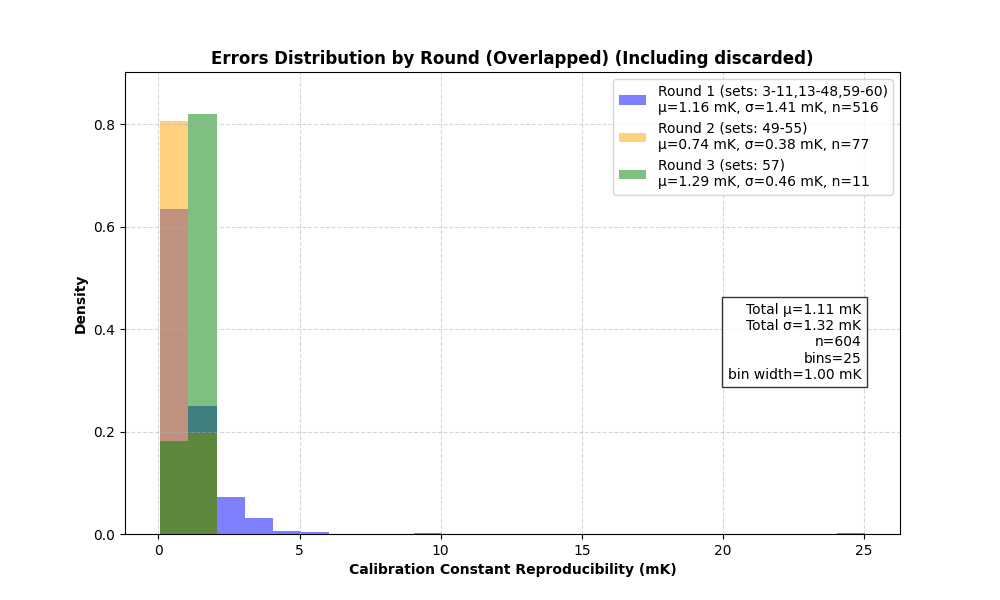


📊 Histograma Subplots (con sensores descartados):


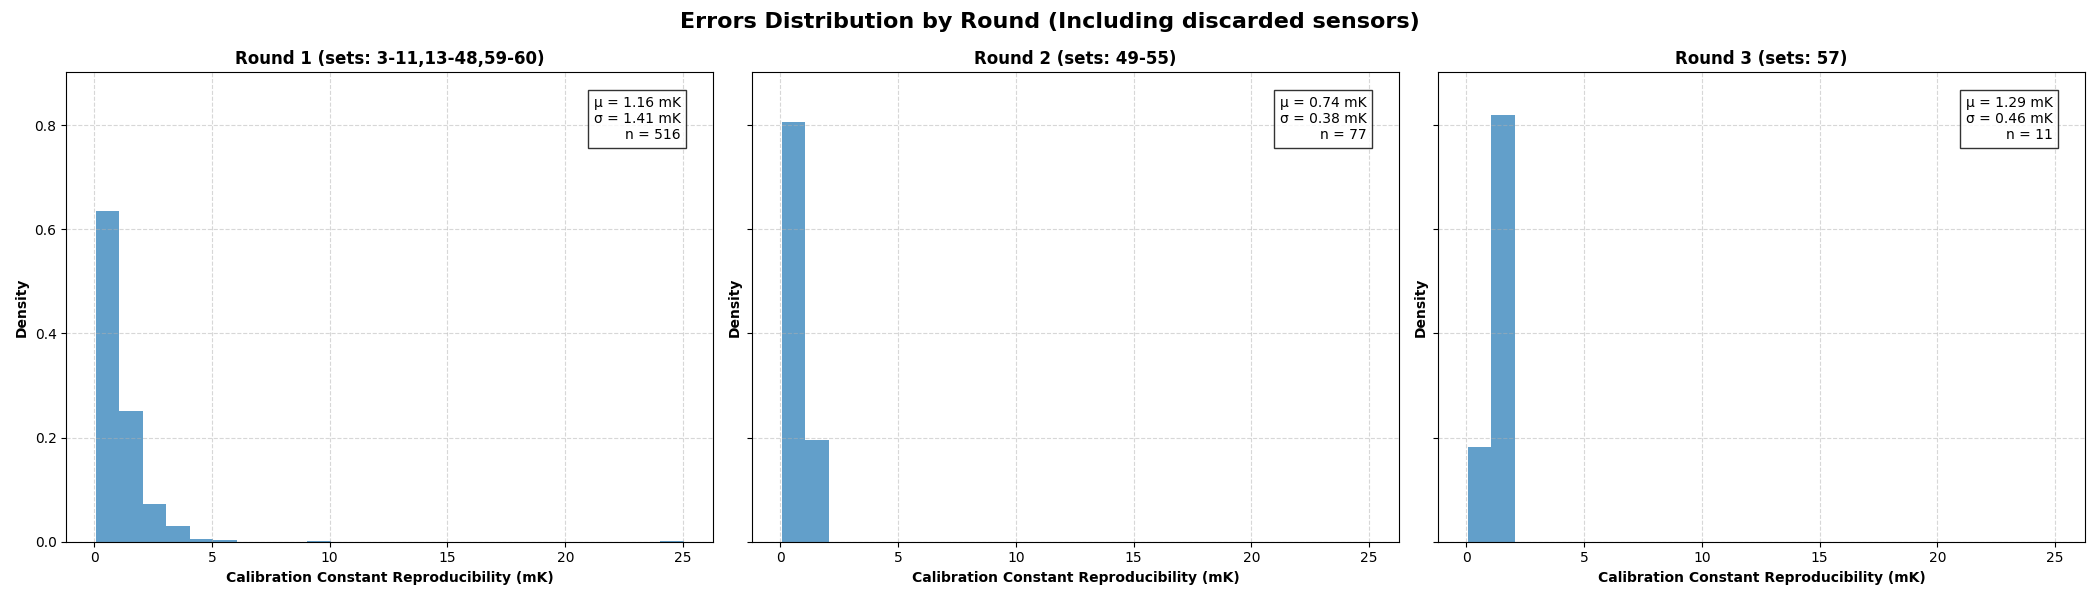


HISTOGRAMAS SIN SENSORES DESCARTADOS (solo válidos)

📊 Histograma Overlapped (sin descartados):


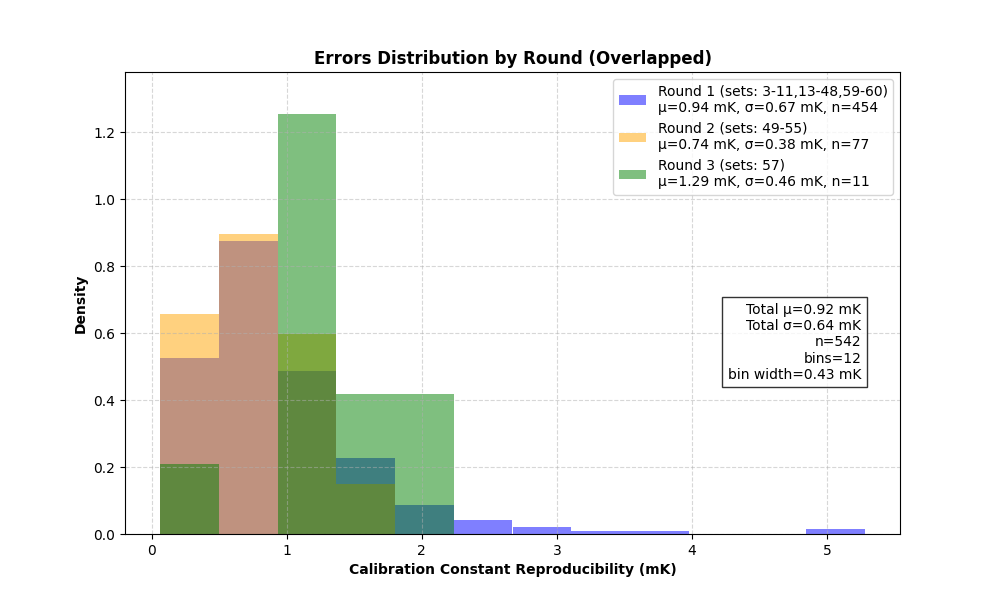


📊 Histograma Subplots (sin descartados):


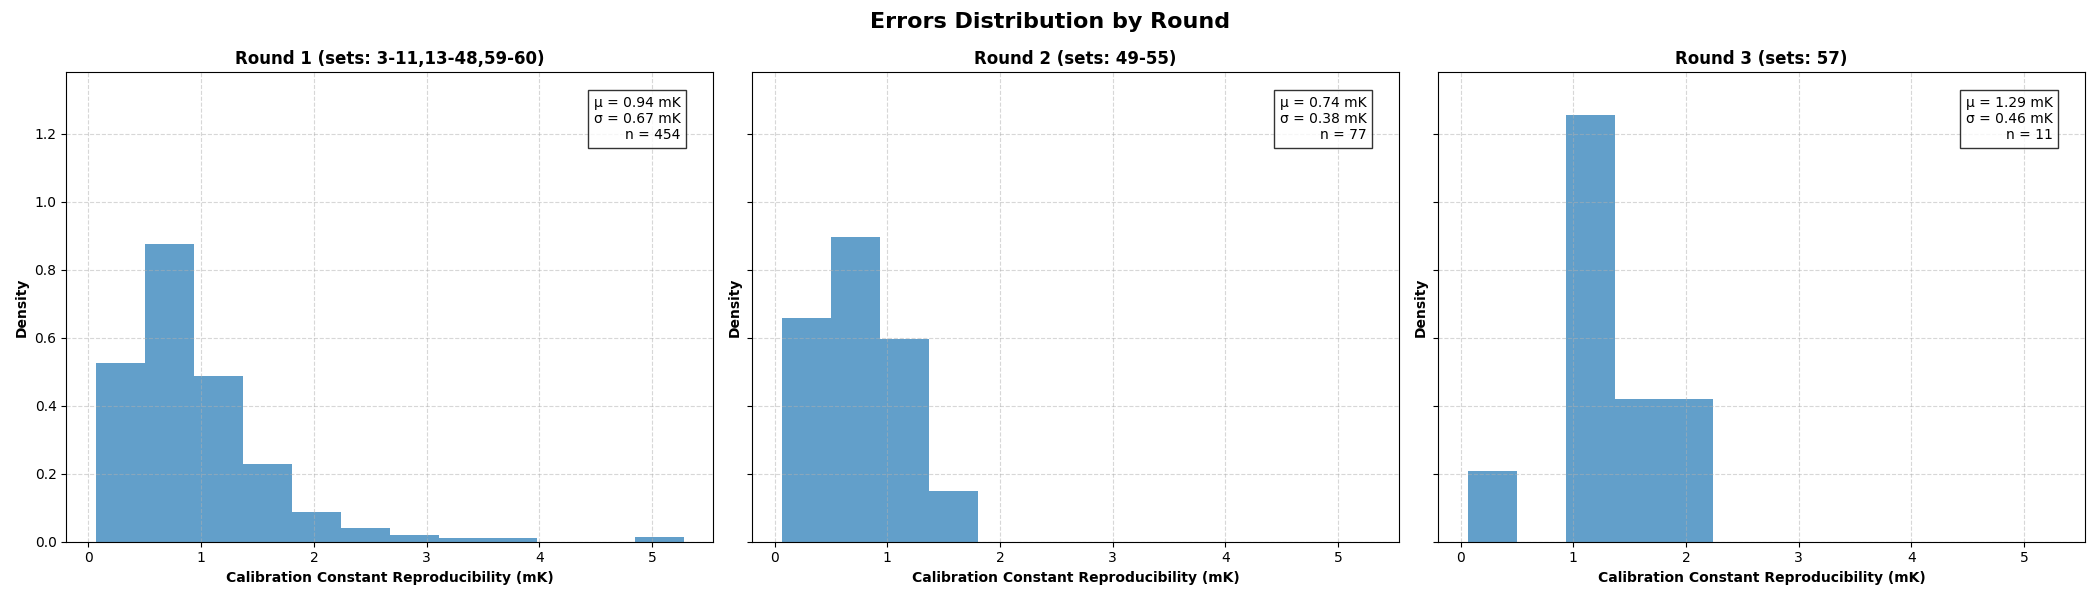

In [5]:
# Mostrar histogramas con sensores descartados (all_sensors)
from IPython.display import Image, display
from pathlib import Path

# Directorio donde se guardaron los histogramas
hist_dir = Path('outputs/histograms_by_round')

print("=" * 80)
print("HISTOGRAMAS INCLUYENDO SENSORES DESCARTADOS (all_sensors)")
print("=" * 80)

# Mostrar histograma overlapped con todos los sensores
overlap_path = hist_dir / 'global_sigma_histogram_rounds_all_sensors_overlap.png'
if overlap_path.exists():
    print("\n📊 Histograma Overlapped (con sensores descartados):")
    display(Image(filename=str(overlap_path)))
else:
    print(f"⚠️  No encontrado: {overlap_path}")

# Mostrar histograma subplots con todos los sensores
subplots_path = hist_dir / 'global_sigma_histogram_rounds_all_sensors_subplots.png'
if subplots_path.exists():
    print("\n📊 Histograma Subplots (con sensores descartados):")
    display(Image(filename=str(subplots_path)))
else:
    print(f"⚠️  No encontrado: {subplots_path}")

print("\n" + "=" * 80)
print("HISTOGRAMAS SIN SENSORES DESCARTADOS (solo válidos)")
print("=" * 80)

# Mostrar histograma overlapped sin descartados (para comparación)
overlap_valid_path = hist_dir / 'global_sigma_histogram_rounds_overlap.png'
if overlap_valid_path.exists():
    print("\n📊 Histograma Overlapped (sin descartados):")
    display(Image(filename=str(overlap_valid_path)))
else:
    print(f"⚠️  No encontrado: {overlap_valid_path}")

# Mostrar histograma subplots sin descartados (para comparación)
subplots_valid_path = hist_dir / 'global_sigma_histogram_rounds_subplots.png'
if subplots_valid_path.exists():
    print("\n📊 Histograma Subplots (sin descartados):")
    display(Image(filename=str(subplots_valid_path)))
else:
    print(f"⚠️  No encontrado: {subplots_valid_path}")

In [6]:
# Mostrar información sobre las rondas cargadas desde config.yml
import pandas as pd

if hasattr(set_instance, 'set_rounds') and set_instance.set_rounds:
    rounds_df = pd.DataFrame([
        {'CalibSetNumber': set_num, 'Round': round_num} 
        for set_num, round_num in set_instance.set_rounds.items()
    ]).sort_values('CalibSetNumber')
    
    print("Información de rondas desde config.yml:")
    print("-" * 50)
    for round_num in sorted(rounds_df['Round'].unique()):
        sets_in_round = rounds_df[rounds_df['Round'] == round_num]['CalibSetNumber'].astype(int).tolist()
        print(f"Round {round_num}: {len(sets_in_round)} sets -> {sets_in_round}")
    print("-" * 50)
    print(f"\nTotal: {len(rounds_df)} sets con información de ronda")
else:
    print("No se encontró información de rondas en la instancia de Set")

Información de rondas desde config.yml:
--------------------------------------------------
Round 1: 48 sets -> [3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 59, 60, 61]
Round 2: 8 sets -> [49, 50, 51, 52, 53, 54, 55, 56]
Round 3: 2 sets -> [57, 62]
Round 4: 1 sets -> [63]
--------------------------------------------------

Total: 59 sets con información de ronda


GLOBAL SIGMA OFFSETS - Errores por Sensor y Set (Con Puntos)

Estos gráficos muestran el error (sigma) de cada sensor a lo largo de todos los sets.
Incluyen TODOS los sensores (con y sin descartados) para ver el comportamiento completo.


📊 Part 1/8: global_sigma_offsets_part_1.png


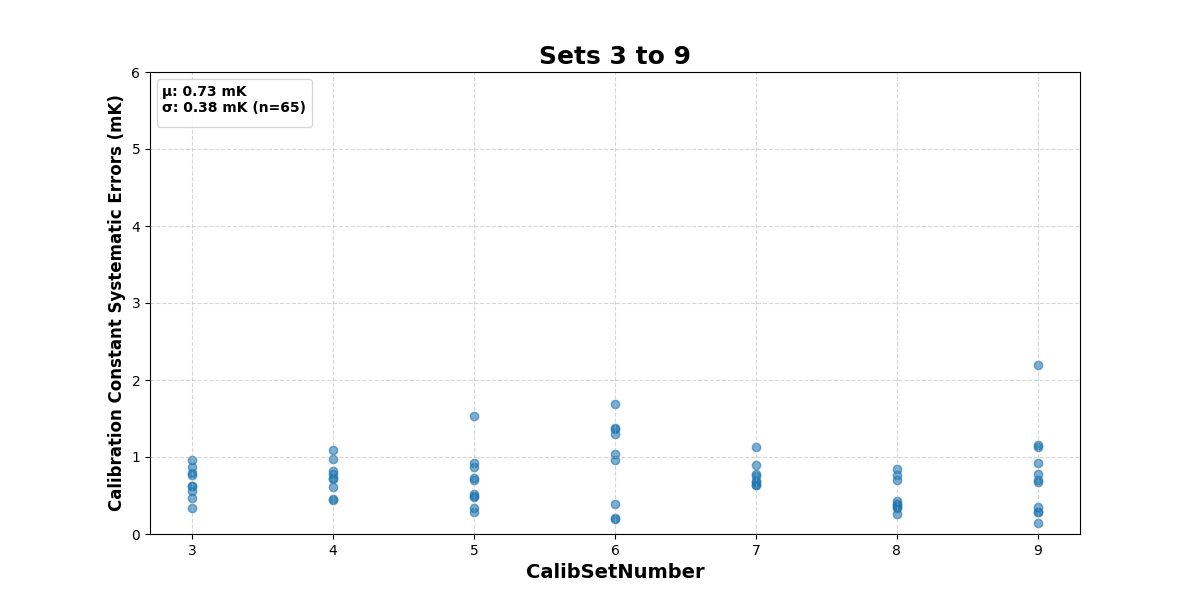


📊 Part 2/8: global_sigma_offsets_part_2.png


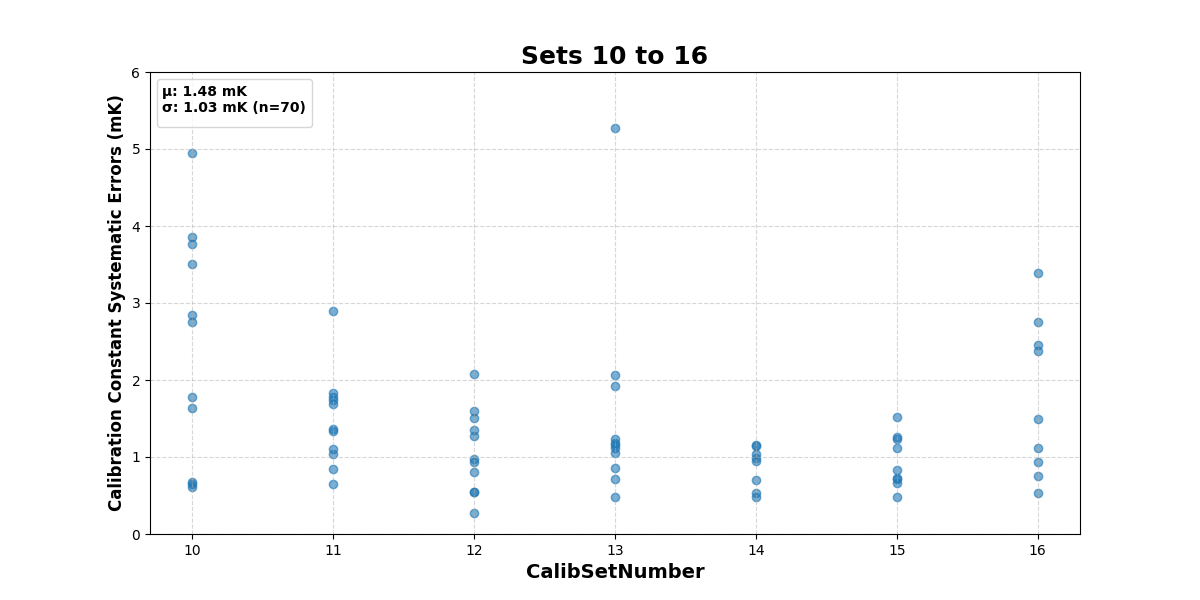


📊 Part 3/8: global_sigma_offsets_part_3.png


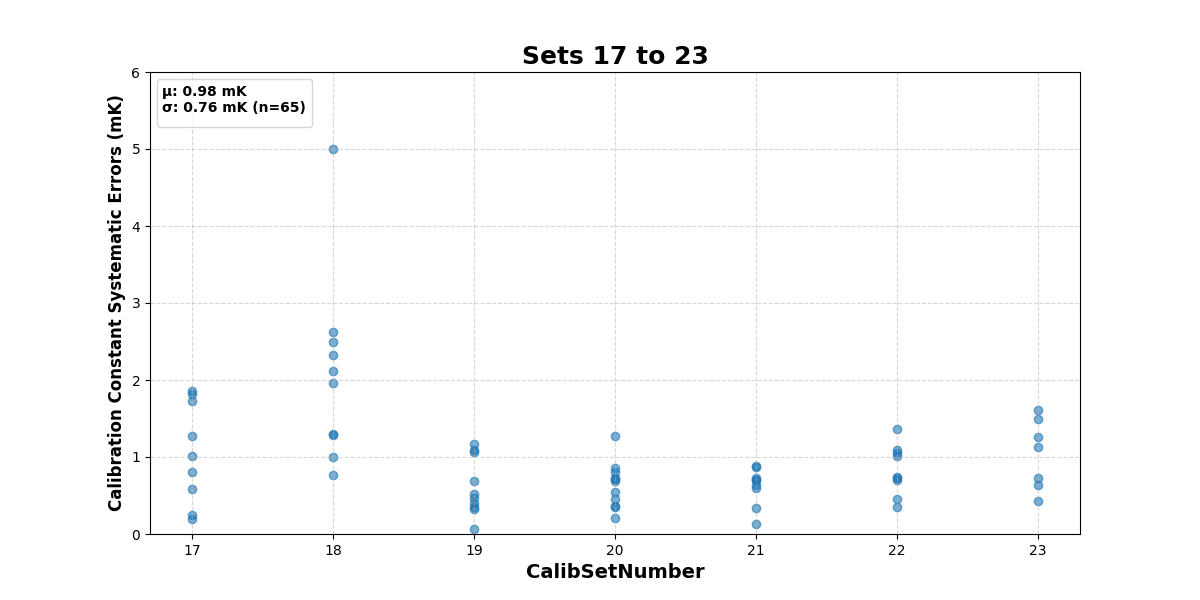


📊 Part 4/8: global_sigma_offsets_part_4.png


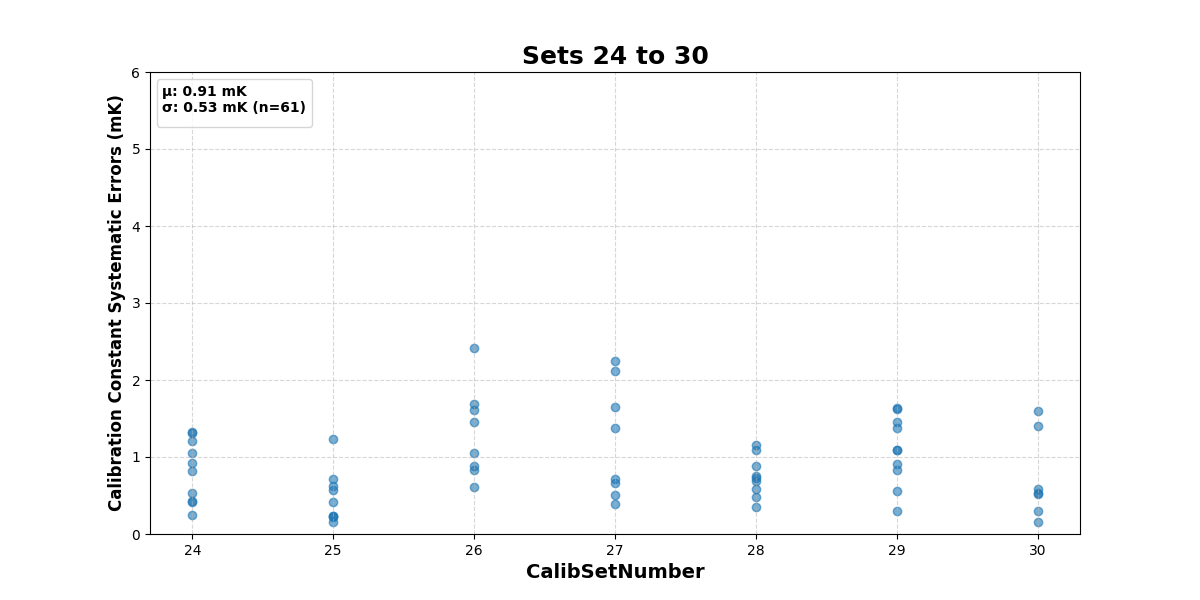


📊 Part 5/8: global_sigma_offsets_part_5.png


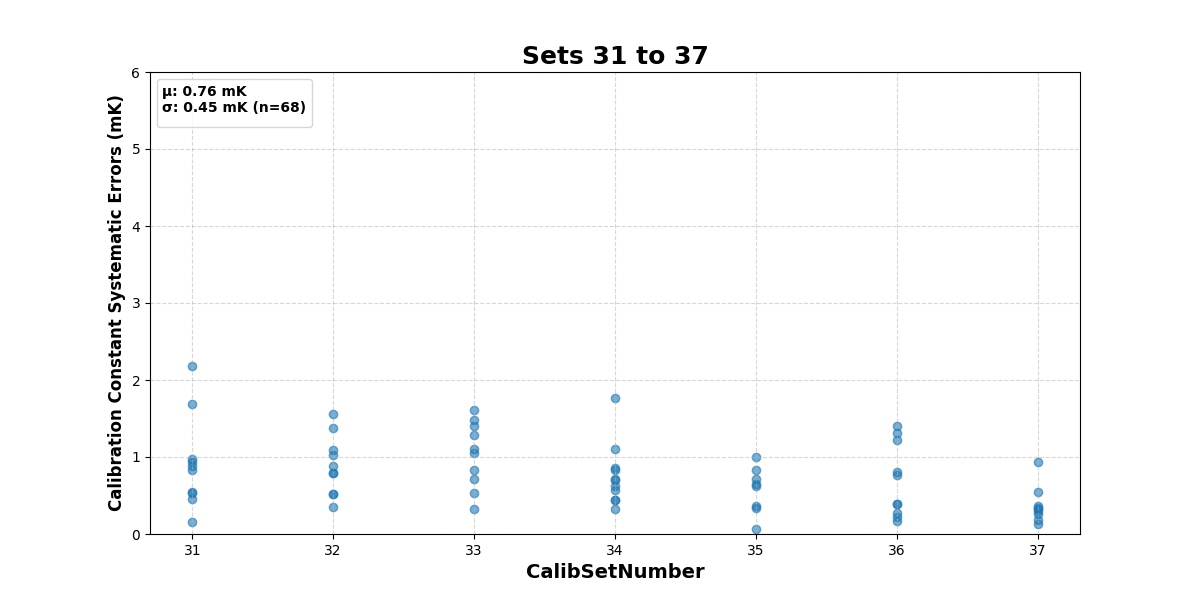


📊 Part 6/8: global_sigma_offsets_part_6.png


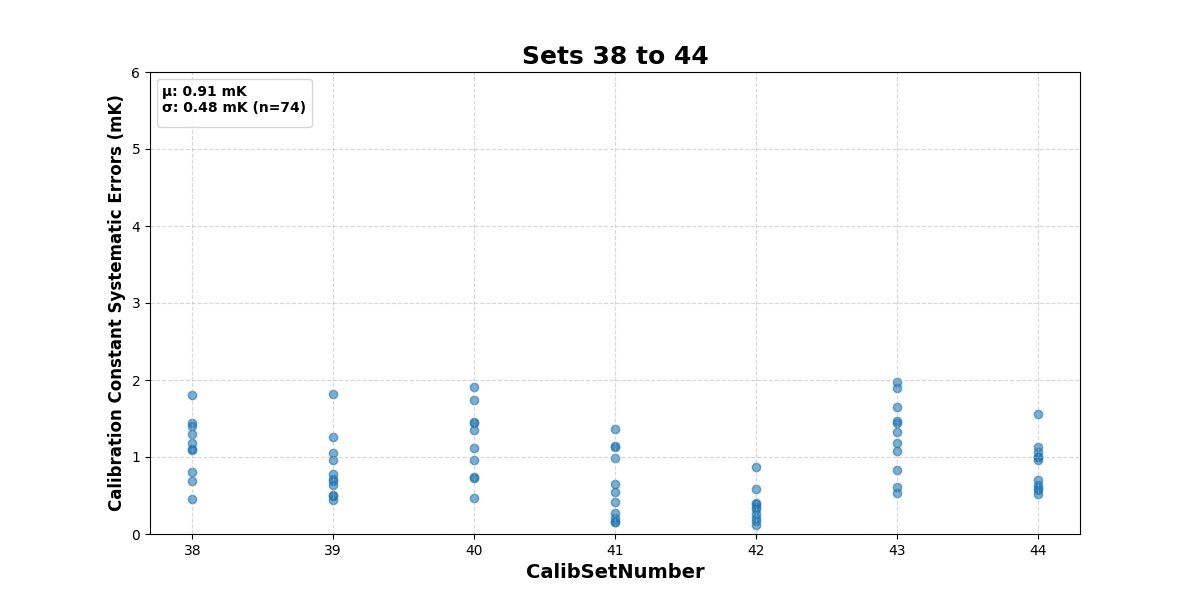


📊 Part 7/8: global_sigma_offsets_part_7.png


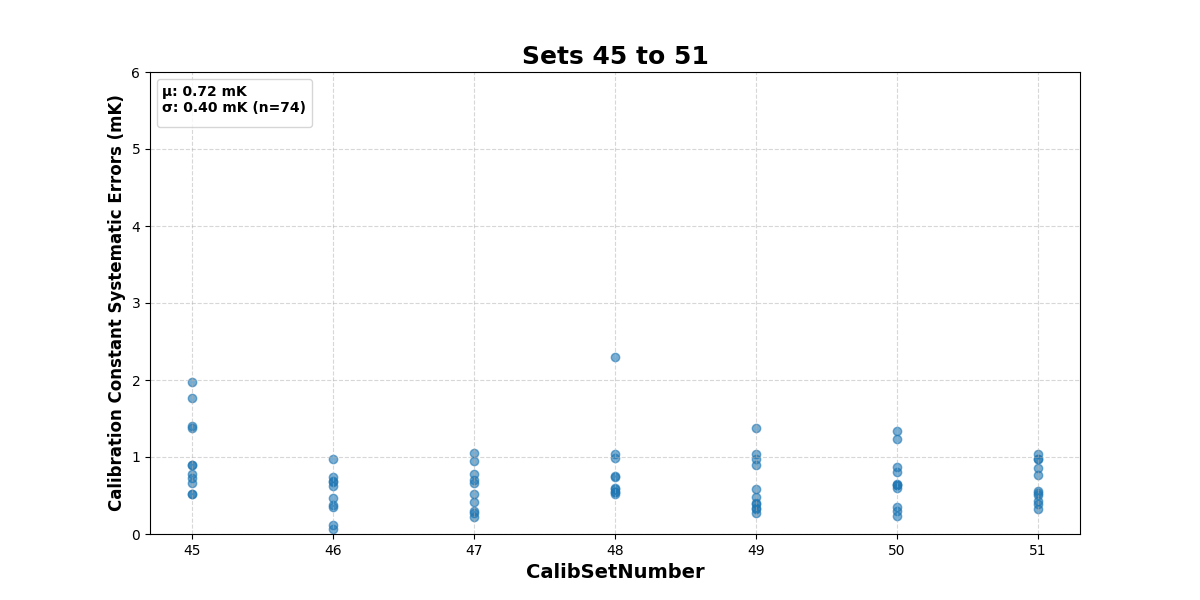


📊 Part 8/8: global_sigma_offsets_part_8.png


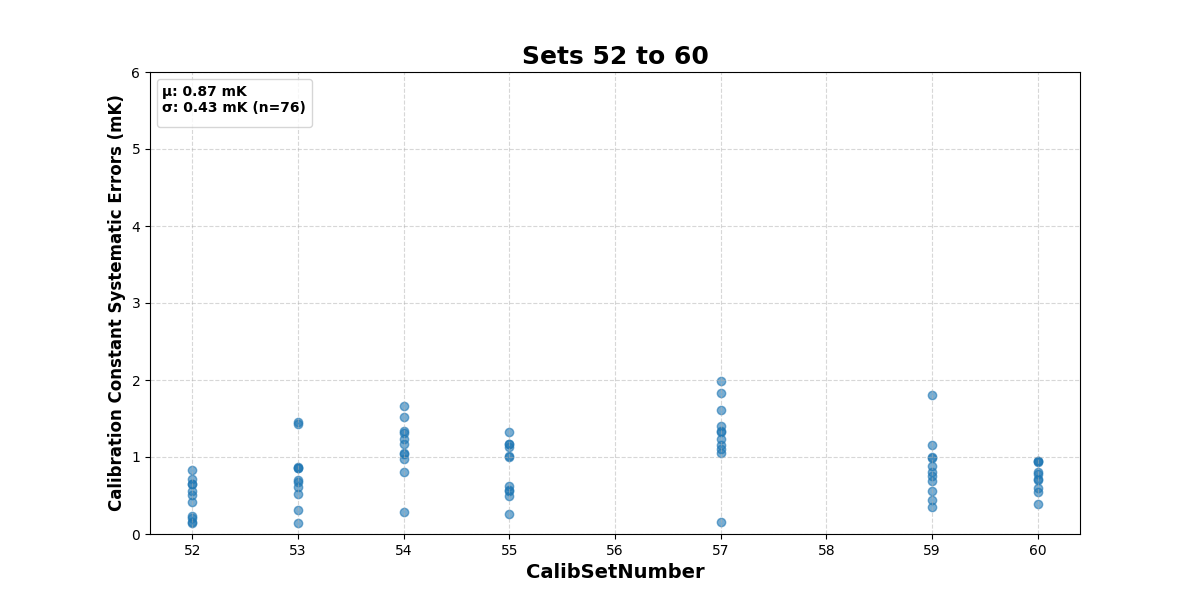


Total de plots mostrados: 8


In [7]:
# Mostrar plots de global sigmas (scatter plots con puntos mostrando sigma vs CalibSetNumber)
from IPython.display import Image, display
from pathlib import Path
import glob

print("=" * 80)
print("GLOBAL SIGMA OFFSETS - Errores por Sensor y Set (Con Puntos)")
print("=" * 80)
print("\nEstos gráficos muestran el error (sigma) de cada sensor a lo largo de todos los sets.")
print("Incluyen TODOS los sensores (con y sin descartados) para ver el comportamiento completo.\n")

# Directorio donde se guardaron los plots
hist_dir = Path('outputs/histograms_by_round')

# Buscar todos los archivos global_sigma_offsets_part_*.png
offset_plots = sorted(hist_dir.glob('global_sigma_offsets_part_*.png'))

if offset_plots:
    for i, plot_path in enumerate(offset_plots, 1):
        print(f"\n{'='*80}")
        print(f"📊 Part {i}/{len(offset_plots)}: {plot_path.name}")
        print(f"{'='*80}")
        display(Image(filename=str(plot_path)))
else:
    print("⚠️  No se encontraron plots de global_sigma_offsets")
    print(f"Buscando en: {hist_dir}")

print("\n" + "=" * 80)
print(f"Total de plots mostrados: {len(offset_plots)}")
print("=" * 80)